# EPL 25시즌 데이터 탐색적 분석 (EDA)
### 2000/01 ~ 2024/25 시즌 프리미어리그 종합 분석

이 노트북은 25시즌 EPL 데이터를 탐색적으로 분석합니다.
- **매치 데이터**: 9,380경기 결과
- **팀 시즌 요약**: 500개 팀-시즌 레코드
- **선수 시즌 통계**: 14,980개 선수-시즌 레코드
- **선수 경기 로그**: 약 30만 건
- **매치 피처**: 77개 파생변수
- **선수 피처**: 63개 파생변수


## 0. 환경 설정 및 라이브러리 로드

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 100

# 경로 설정
BASE = Path(r'C:/Users/xcv54/workspace/EPL project')
FIG_DIR = BASE / 'reports' / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

PROCESSED = BASE / 'data' / 'processed'
FEATURES = BASE / 'data' / 'features'

# 색상 팔레트
COLORS = sns.color_palette('husl', 12)
BIG6_COLORS = {'Arsenal': '#EF0107', 'Chelsea': '#034694', 'Liverpool': '#C8102E',
               'Man City': '#6CABDD', 'Man United': '#DA291C', 'Tottenham': '#132257'}

print('환경 설정 완료')


환경 설정 완료


## 1. 데이터 개요

In [2]:
# 모든 데이터셋 로드
match_results = pd.read_parquet(PROCESSED / 'match_results.parquet')
team_season = pd.read_parquet(PROCESSED / 'team_season_summary.parquet')
player_stats = pd.read_parquet(PROCESSED / 'player_season_stats.parquet')
player_logs = pd.read_parquet(PROCESSED / 'player_match_logs.parquet')
match_features = pd.read_parquet(FEATURES / 'match_features.parquet')
player_features = pd.read_parquet(FEATURES / 'player_features.parquet')

datasets = {
    'match_results': match_results,
    'team_season_summary': team_season,
    'player_season_stats': player_stats,
    'player_match_logs': player_logs,
    'match_features': match_features,
    'player_features': player_features,
}

print('=' * 70)
print(f'{"데이터셋":<25} {"행":>8} {"열":>5}  기간')
print('=' * 70)
for name, df in datasets.items():
    season_col = [c for c in df.columns if c.lower() in ('season', 'season')]
    if season_col:
        seasons = df[season_col[0]].nunique()
        s_range = f'{df[season_col[0]].min()} ~ {df[season_col[0]].max()}'
    else:
        seasons = '-'
        s_range = '-'
    print(f'{name:<25} {df.shape[0]:>8,} {df.shape[1]:>5}  {s_range}')
print('=' * 70)


데이터셋                             행     열  기간
match_results                9,380    26  2000/01 ~ 2024/25
team_season_summary            500    22  2000/01 ~ 2024/25
player_season_stats         14,980    36  2000/01 ~ 2024/25
player_match_logs          299,517    33  2000/01 ~ 2024/25
match_features               9,380    77  2000/01 ~ 2024/25
player_features             14,980    63  2000/01 ~ 2024/25


In [3]:
# 각 데이터셋 샘플 확인
for name, df in datasets.items():
    print(f'\n{"="*60}')
    print(f'📊 {name} — {df.shape[0]:,}행 × {df.shape[1]}열')
    print(f'{"="*60}')
    print(df.dtypes.to_string())
    print(f'\n샘플 데이터:')
    display(df.head(3))



📊 match_results — 9,380행 × 26열
Season                         object
MatchDate              datetime64[ns]
HomeTeam                       object
AwayTeam                       object
FullTimeHomeGoals               int64
FullTimeAwayGoals               int64
FullTimeResult                 object
HalfTimeHomeGoals               int64
HalfTimeAwayGoals               int64
HalfTimeResult                 object
HomeShots                       int64
AwayShots                       int64
HomeShotsOnTarget               int64
AwayShotsOnTarget               int64
HomeCorners                     int64
AwayCorners                     int64
HomeFouls                       int64
AwayFouls                       int64
HomeYellowCards                 int64
AwayYellowCards                 int64
HomeRedCards                    int64
AwayRedCards                    int64
season_data_missing              bool
own_goal_flag_home               bool
own_goal_flag_away               bool
own_goal_flag     

,Season,MatchDate,HomeTeam,AwayTeam,FullTimeHomeGoals,FullTimeAwayGoals,FullTimeResult,HalfTimeHomeGoals,HalfTimeAwayGoals,HalfTimeResult,...,HomeFouls,AwayFouls,HomeYellowCards,AwayYellowCards,HomeRedCards,AwayRedCards,season_data_missing,own_goal_flag_home,own_goal_flag_away,own_goal_flag
0,2000/01,2000-08-19,Charlton,Man City,4,0,H,2,0,H,...,13,12,1,2,0,0,False,False,False,False
1,2000/01,2000-08-19,Chelsea,West Ham,4,2,H,1,0,H,...,19,14,1,2,0,0,False,False,False,False
2,2000/01,2000-08-19,Coventry,Middlesbrough,1,3,A,1,1,D,...,15,21,5,3,1,0,False,False,False,False



📊 team_season_summary — 500행 × 22열
Season                 object
team                   object
home_played             int64
home_wins               int64
home_draws              int64
home_losses             int64
home_goals_for          int64
home_goals_against      int64
away_played             int64
away_wins               int64
away_draws              int64
away_losses             int64
away_goals_for          int64
away_goals_against      int64
total_played            int64
total_wins              int64
total_draws             int64
total_losses            int64
total_goals_for         int64
total_goals_against     int64
goal_diff               int64
points                  int64

샘플 데이터:


,Season,team,home_played,home_wins,home_draws,home_losses,home_goals_for,home_goals_against,away_played,away_wins,...,away_goals_for,away_goals_against,total_played,total_wins,total_draws,total_losses,total_goals_for,total_goals_against,goal_diff,points
0,2000/01,Arsenal,19,15,3,1,45,13,19,5,...,18,25,38,20,10,8,63,38,25,70
1,2000/01,Aston Villa,19,8,8,3,27,20,19,5,...,19,23,38,13,15,10,46,43,3,54
2,2000/01,Bradford,19,4,7,8,20,29,19,1,...,10,41,38,5,11,22,30,70,-40,26



📊 player_season_stats — 14,980행 × 36열
player                      object
nation                      object
pos                         object
age                        float64
mp                           int64
starts                     float64
min                        float64
90s                        float64
gls                        float64
ast                        float64
g_a                        float64
g_pk                       float64
pk                         float64
pkatt                      float64
crdy                         int64
crdr                         int64
gls_1                      float64
ast_1                      float64
g_a_1                      float64
g_pk_1                     float64
g_a_pk                     float64
season                      object
team                        object
transfer_flag                 bool
player_id                  float64
position                    object
dob                 datetime64[ns]
age_tm          

...

,date,day,comp,round,venue,result,squad,opponent,pos,min,...,int,og,season,team,player,outcome,goals_for,goals_against,started,detail_stats_available
0,2000-11-18,Sat,Premier League,Matchweek 14,Away,L 0–2,Arsenal,Everton,None,90.0,...,NaN,0.0,2000/01,Arsenal,Alex Manninger,L,0,2,True,False
1,2000-11-26,Sun,Premier League,Matchweek 15,Away,L 0–1,Arsenal,Leeds,None,90.0,...,NaN,0.0,2000/01,Arsenal,Alex Manninger,L,0,1,True,False
2,2000-12-02,Sat,Premier League,Matchweek 16,Home,W 1–0,Arsenal,Southampton,None,90.0,...,NaN,0.0,2000/01,Arsenal,Alex Manninger,W,1,0,True,False



📊 match_features — 9,380행 × 77열
Season                            object
MatchDate                 datetime64[ns]
HomeTeam                          object
AwayTeam                          object
FullTimeHomeGoals                  int64
FullTimeAwayGoals                  int64
FullTimeResult                    object
HalfTimeHomeGoals                  int64
HalfTimeAwayGoals                  int64
HalfTimeResult                    object
HomeShots                          int64
AwayShots                          int64
HomeShotsOnTarget                  int64
AwayShotsOnTarget                  int64
HomeCorners                        int64
AwayCorners                        int64
HomeFouls                          int64
AwayFouls                          int64
HomeYellowCards                    int64
AwayYellowCards                    int64
HomeRedCards                       int64
AwayRedCards                       int64
season_data_missing                 bool
own_goal_flag_home      

,Season,MatchDate,HomeTeam,AwayTeam,FullTimeHomeGoals,FullTimeAwayGoals,FullTimeResult,HalfTimeHomeGoals,HalfTimeAwayGoals,HalfTimeResult,...,home_promoted,away_promoted,matchweek,season_stage,form_diff_5,form_diff_10,gd_trend_diff,is_derby,is_weekend,data_split
0,2000/01,2000-08-19,Charlton,Man City,4,0,H,2,0,H,...,1,1,1,early,NaN,NaN,NaN,0,1,train
1,2000/01,2000-08-19,Chelsea,West Ham,4,2,H,1,0,H,...,1,1,1,early,NaN,NaN,NaN,0,1,train
2,2000/01,2000-08-19,Coventry,Middlesbrough,1,3,A,1,1,D,...,1,1,1,early,NaN,NaN,NaN,0,1,train



📊 player_features — 14,980행 × 63열
player                              object
nation                              object
pos                                 object
age                                float64
mp                                   int64
starts                             float64
min                                float64
90s                                float64
gls                                float64
ast                                float64
g_a                                float64
g_pk                               float64
pk                                 float64
pkatt                              float64
crdy                                 int64
crdr                                 int64
gls_1                              float64
ast_1                              float64
g_a_1                              float64
g_pk_1                             float64
g_a_pk                             float64
season                              object
team               

,player,nation,pos,age,mp,starts,min,90s,gls,ast,...,mv_prev,mv_change_pct,mv_per_goal_contribution,epl_experience,consistency_std,consistency_mean,consistency_cv,n_matches,versatility_positions,data_split
0,Aaron Anselmino,ar ARG,DF,19.0,0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,test
1,Aaron Connolly,ie IRL,FW,19.0,24,14.0,1258.0,14.0,3.0,1.0,...,NaN,NaN,1.000000e+06,0,0.448395,0.142857,3.138766,28.0,2.0,train
2,Aaron Connolly,ie IRL,"FW,MF",20.0,17,9.0,791.0,8.8,2.0,1.0,...,4000000.0,75.0,2.333333e+06,1,0.314970,0.107143,2.939724,28.0,3.0,train


## 2. 결측치 분석

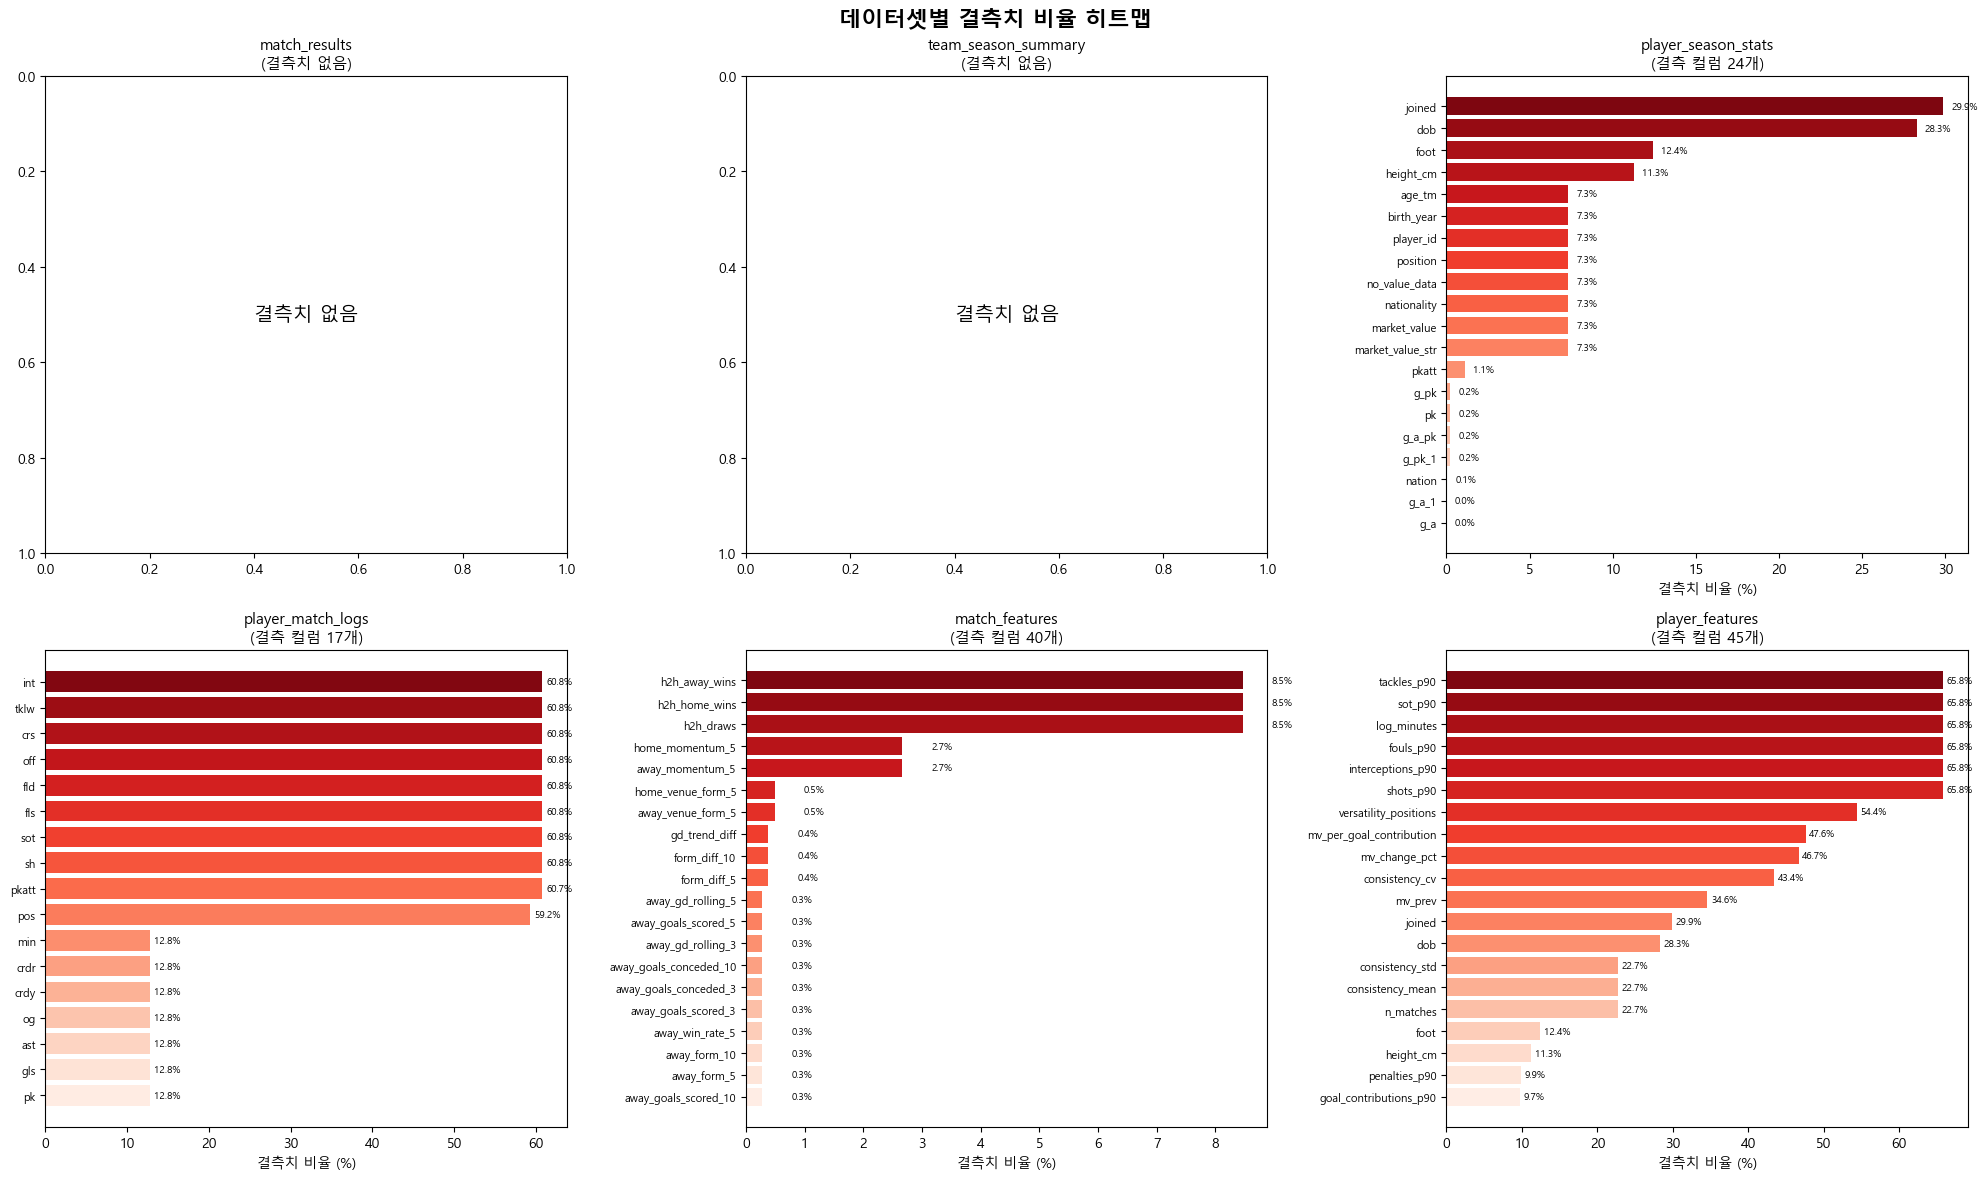

결측치 히트맵 저장 완료


In [4]:
# 결측치 비율 계산
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('데이터셋별 결측치 비율 히트맵', fontsize=16, fontweight='bold')

for idx, (name, df) in enumerate(datasets.items()):
    ax = axes[idx // 3, idx % 3]
    missing_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
    missing_cols = missing_pct[missing_pct > 0]

    if len(missing_cols) == 0:
        ax.text(0.5, 0.5, '결측치 없음', ha='center', va='center', fontsize=14, transform=ax.transAxes)
        ax.set_title(f'{name}\n(결측치 없음)', fontsize=11)
    else:
        top_missing = missing_cols.head(20)
        ax.barh(range(len(top_missing)), top_missing.values, color=sns.color_palette('Reds_r', len(top_missing)))
        ax.set_yticks(range(len(top_missing)))
        ax.set_yticklabels(top_missing.index, fontsize=8)
        ax.set_xlabel('결측치 비율 (%)')
        ax.set_title(f'{name}\n(결측 컬럼 {len(missing_cols)}개)', fontsize=11)
        for i, v in enumerate(top_missing.values):
            ax.text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=7)
    ax.invert_yaxis()

plt.tight_layout()
plt.savefig(FIG_DIR / 'eda_missing_values.png', dpi=150, bbox_inches='tight')
plt.show()
print('결측치 히트맵 저장 완료')


In [5]:
# 결측치 요약 테이블
print('\n데이터셋별 결측치 요약')
print('=' * 60)
for name, df in datasets.items():
    total_cells = df.shape[0] * df.shape[1]
    missing_cells = df.isnull().sum().sum()
    missing_cols = (df.isnull().sum() > 0).sum()
    pct = missing_cells / total_cells * 100
    print(f'{name:<25} 전체셀={total_cells:>10,}  결측={missing_cells:>8,} ({pct:.2f}%)  결측컬럼={missing_cols}')



데이터셋별 결측치 요약
match_results             전체셀=   243,880  결측=       0 (0.00%)  결측컬럼=0
team_season_summary       전체셀=    11,000  결측=       0 (0.00%)  결측컬럼=0
player_season_stats       전체셀=   539,280  결측=  21,343 (3.96%)  결측컬럼=24


player_match_logs         전체셀= 9,884,061  결측=2,082,802 (21.07%)  결측컬럼=17
match_features            전체셀=   722,260  결측=   3,769 (0.52%)  결측컬럼=40
player_features           전체셀=   943,740  결측= 134,634 (14.27%)  결측컬럼=45


## 3. 시즌별 분석

### 3.1 시즌별 평균 골 수 추이

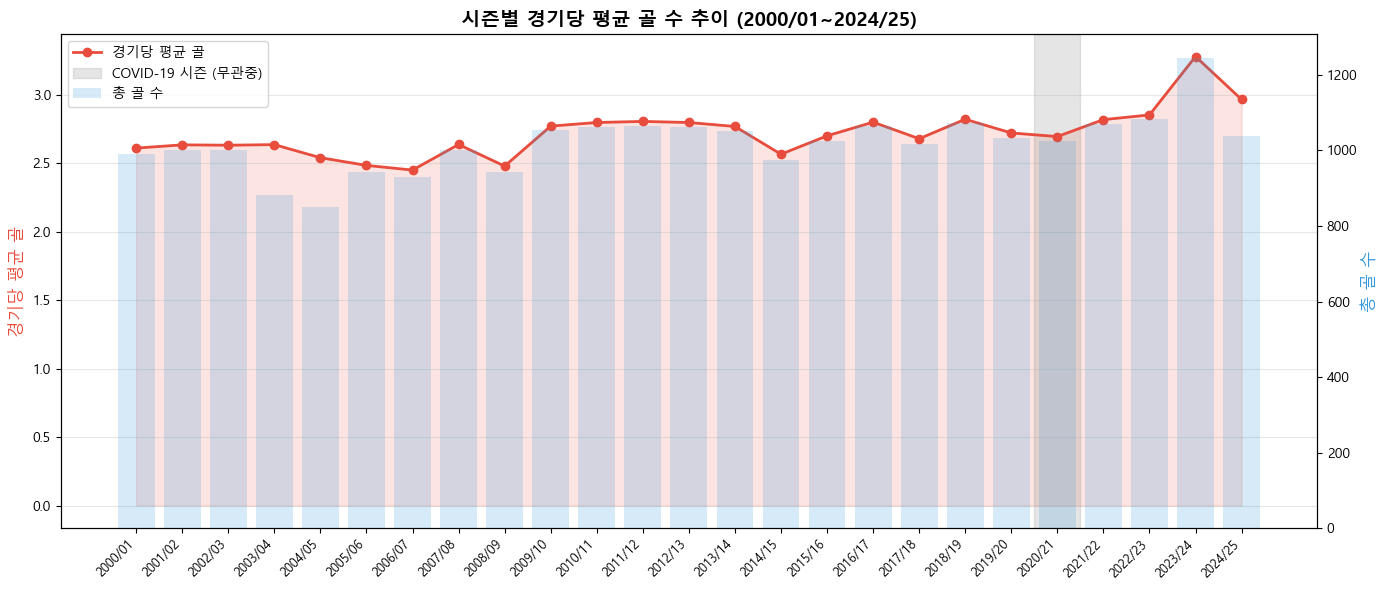

전체 평균 골: 2.72골/경기
최고 시즌: 2023/24 (3.28골)
최저 시즌: 2006/07 (2.45골)


In [6]:
# 시즌별 평균 골
mr = match_results.copy()
mr['TotalGoals'] = mr['FullTimeHomeGoals'] + mr['FullTimeAwayGoals']
season_goals = mr.groupby('Season').agg(
    avg_goals=('TotalGoals', 'mean'),
    total_goals=('TotalGoals', 'sum'),
    matches=('TotalGoals', 'count')
).reset_index()

fig, ax1 = plt.subplots(figsize=(14, 6))
ax1.plot(range(len(season_goals)), season_goals['avg_goals'], 'o-', color='#E74C3C', linewidth=2, markersize=6, label='경기당 평균 골')
ax1.fill_between(range(len(season_goals)), season_goals['avg_goals'], alpha=0.15, color='#E74C3C')
ax1.set_xticks(range(len(season_goals)))
ax1.set_xticklabels(season_goals['Season'], rotation=45, ha='right', fontsize=9)
ax1.set_ylabel('경기당 평균 골', fontsize=12, color='#E74C3C')
ax1.set_title('시즌별 경기당 평균 골 수 추이 (2000/01~2024/25)', fontsize=14, fontweight='bold')

# COVID 마킹
covid_idx = list(season_goals['Season']).index('2020/21') if '2020/21' in list(season_goals['Season']) else None
if covid_idx is not None:
    ax1.axvspan(covid_idx - 0.5, covid_idx + 0.5, alpha=0.2, color='gray', label='COVID-19 시즌 (무관중)')

ax2 = ax1.twinx()
ax2.bar(range(len(season_goals)), season_goals['total_goals'], alpha=0.2, color='#3498DB', label='총 골 수')
ax2.set_ylabel('총 골 수', fontsize=12, color='#3498DB')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
ax1.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / 'eda_season_avg_goals.png', dpi=150, bbox_inches='tight')
plt.show()

overall_avg = mr['TotalGoals'].mean()
print(f'전체 평균 골: {overall_avg:.2f}골/경기')
print(f'최고 시즌: {season_goals.loc[season_goals["avg_goals"].idxmax(), "Season"]} ({season_goals["avg_goals"].max():.2f}골)')
print(f'최저 시즌: {season_goals.loc[season_goals["avg_goals"].idxmin(), "Season"]} ({season_goals["avg_goals"].min():.2f}골)')


### 3.2 시즌별 경기 결과 비율 (홈승/무승부/원정승)

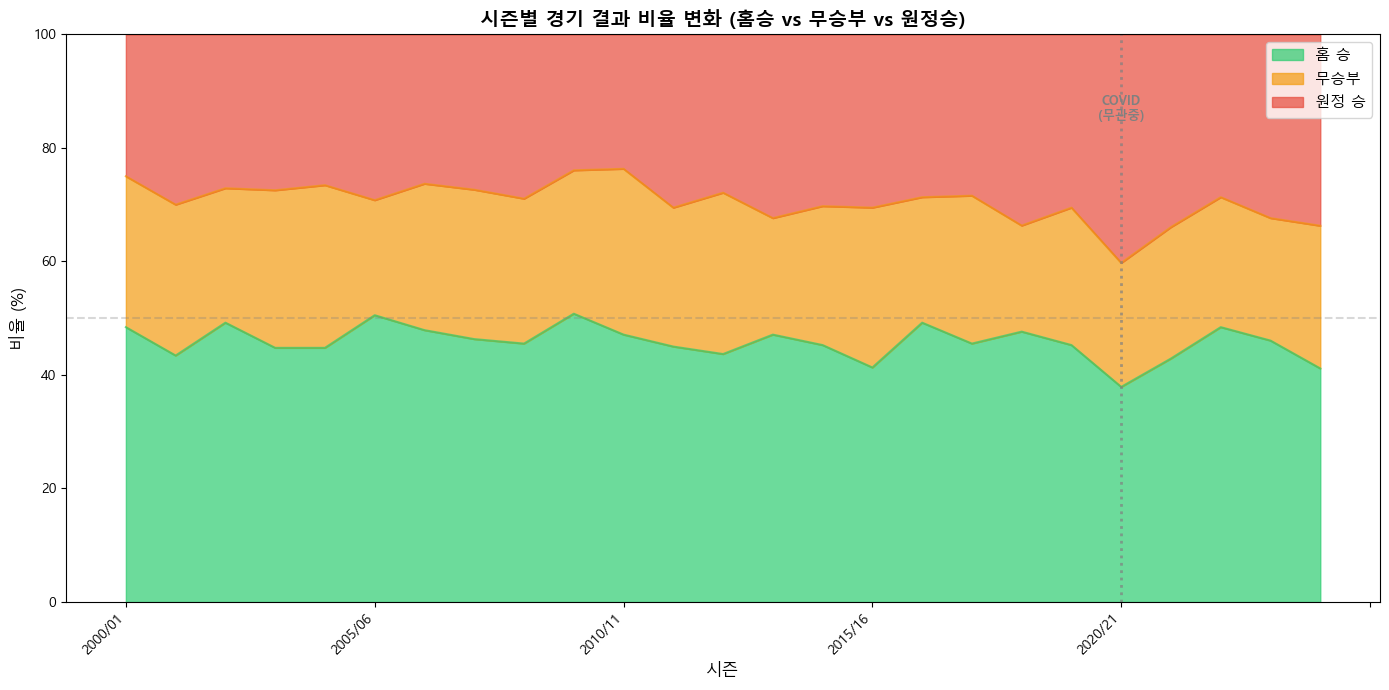

전체 홈승률: 45.8%
전체 무승부율: 24.7%
전체 원정승률: 29.5%


In [7]:
# 경기 결과 비율
result_pct = mr.groupby('Season')['FullTimeResult'].value_counts(normalize=True).unstack(fill_value=0) * 100
result_pct = result_pct.reindex(columns=['H', 'D', 'A'])
result_pct.columns = ['홈 승', '무승부', '원정 승']

fig, ax = plt.subplots(figsize=(14, 7))
result_pct.plot.area(ax=ax, stacked=True, alpha=0.7, color=['#2ECC71', '#F39C12', '#E74C3C'])
ax.set_ylabel('비율 (%)', fontsize=12)
ax.set_title('시즌별 경기 결과 비율 변화 (홈승 vs 무승부 vs 원정승)', fontsize=14, fontweight='bold')
ax.set_xlabel('시즌', fontsize=12)
ax.legend(fontsize=11, loc='upper right')
ax.set_ylim(0, 100)
ax.axhline(y=50, color='gray', linestyle='--', alpha=0.3)

# COVID 마킹
if covid_idx is not None:
    ax.axvline(x=result_pct.index.get_loc('2020/21'), color='gray', linestyle=':', alpha=0.7, linewidth=2)
    ax.annotate('COVID\n(무관중)', xy=(result_pct.index.get_loc('2020/21'), 85), fontsize=9,
                ha='center', color='gray', fontweight='bold')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(FIG_DIR / 'eda_result_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'전체 홈승률: {(mr["FullTimeResult"]=="H").mean()*100:.1f}%')
print(f'전체 무승부율: {(mr["FullTimeResult"]=="D").mean()*100:.1f}%')
print(f'전체 원정승률: {(mr["FullTimeResult"]=="A").mean()*100:.1f}%')


### 3.3 홈 어드밴티지 추이 (COVID-19 영향 포함)

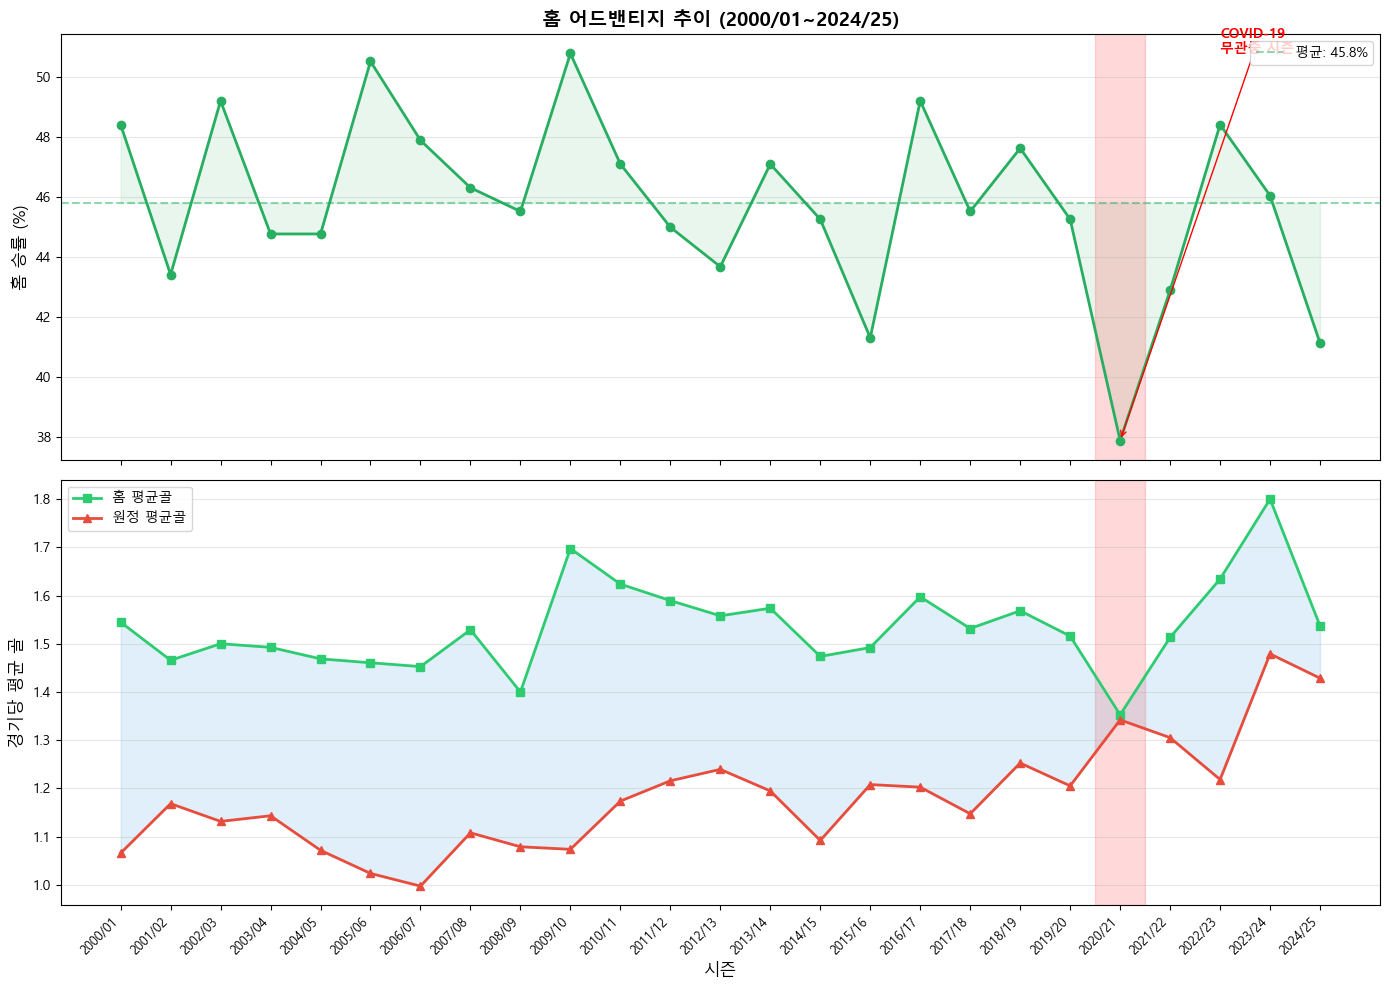

COVID 시즌 홈승률: 37.9% (직전 3시즌 평균: 46.1%)
홈 어드밴티지 감소: 8.2%p


In [8]:
# 홈 어드밴티지 추이
home_adv = mr.groupby('Season').apply(
    lambda x: pd.Series({
        '홈승률': (x['FullTimeResult'] == 'H').mean() * 100,
        '홈 평균골': x['FullTimeHomeGoals'].mean(),
        '원정 평균골': x['FullTimeAwayGoals'].mean(),
        '홈골_우위': x['FullTimeHomeGoals'].mean() - x['FullTimeAwayGoals'].mean()
    })
).reset_index()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# 홈승률
ax1.plot(range(len(home_adv)), home_adv['홈승률'], 'o-', color='#27AE60', linewidth=2, markersize=6)
ax1.axhline(y=home_adv['홈승률'].mean(), color='#27AE60', linestyle='--', alpha=0.5, label=f'평균: {home_adv["홈승률"].mean():.1f}%')
ax1.fill_between(range(len(home_adv)), home_adv['홈승률'], home_adv['홈승률'].mean(), alpha=0.1, color='#27AE60')
ax1.set_ylabel('홈 승률 (%)', fontsize=12)
ax1.set_title('홈 어드밴티지 추이 (2000/01~2024/25)', fontsize=14, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(axis='y', alpha=0.3)

# COVID 마킹
if covid_idx is not None:
    for ax in [ax1, ax2]:
        ax.axvspan(covid_idx - 0.5, covid_idx + 0.5, alpha=0.15, color='red')
    ax1.annotate('COVID-19\n무관중 시즌', xy=(covid_idx, home_adv.iloc[covid_idx]['홈승률']),
                 xytext=(covid_idx + 2, home_adv['홈승률'].max()),
                 arrowprops=dict(arrowstyle='->', color='red'), fontsize=10, color='red', fontweight='bold')

# 홈/원정 평균골
ax2.plot(range(len(home_adv)), home_adv['홈 평균골'], 's-', color='#2ECC71', linewidth=2, label='홈 평균골')
ax2.plot(range(len(home_adv)), home_adv['원정 평균골'], '^-', color='#E74C3C', linewidth=2, label='원정 평균골')
ax2.fill_between(range(len(home_adv)), home_adv['홈 평균골'], home_adv['원정 평균골'], alpha=0.15, color='#3498DB')
ax2.set_xticks(range(len(home_adv)))
ax2.set_xticklabels(home_adv['Season'], rotation=45, ha='right', fontsize=9)
ax2.set_ylabel('경기당 평균 골', fontsize=12)
ax2.set_xlabel('시즌', fontsize=12)
ax2.legend(fontsize=10)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / 'eda_home_advantage.png', dpi=150, bbox_inches='tight')
plt.show()

if covid_idx is not None:
    covid_home = home_adv.iloc[covid_idx]['홈승률']
    pre_covid = home_adv.iloc[covid_idx-3:covid_idx]['홈승률'].mean()
    print(f'COVID 시즌 홈승률: {covid_home:.1f}% (직전 3시즌 평균: {pre_covid:.1f}%)')
    print(f'홈 어드밴티지 감소: {pre_covid - covid_home:.1f}%p')


## 4. 팀 분석

### 4.1 역대 총 승수 Top 10

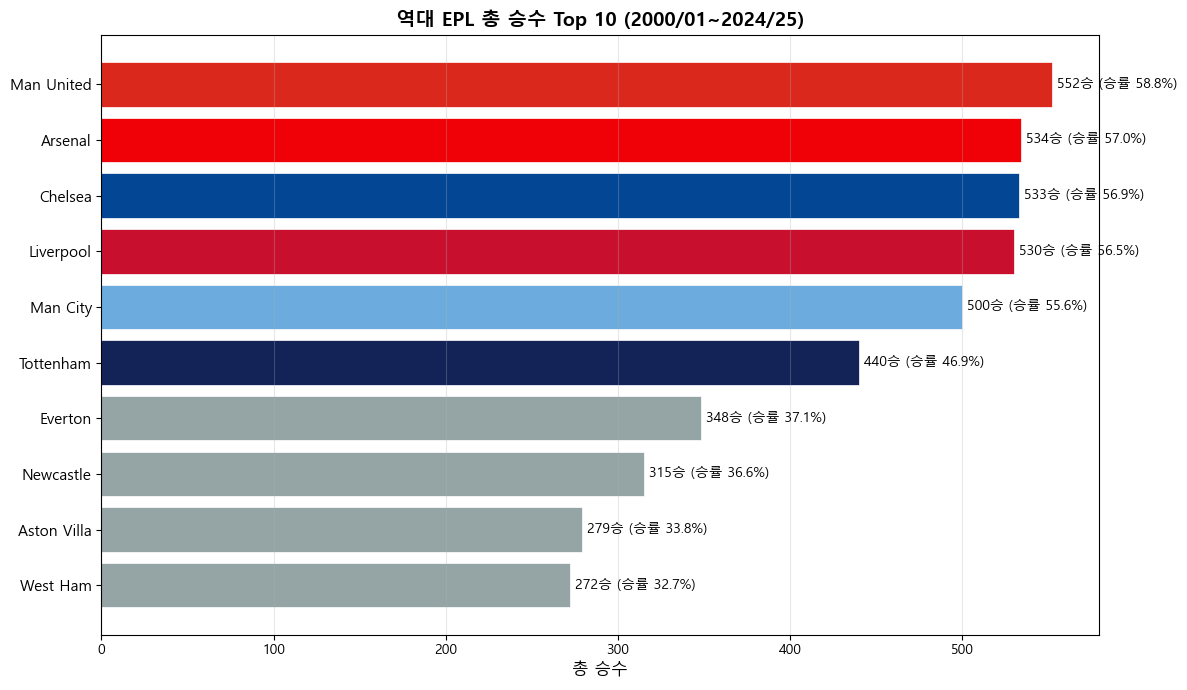

In [9]:
# Top 10 팀 by 승수
ts = team_season.copy()
team_total = ts.groupby('team').agg(
    total_wins=('total_wins', 'sum'),
    total_losses=('total_losses', 'sum'),
    total_draws=('total_draws', 'sum'),
    total_gf=('total_goals_for', 'sum'),
    total_ga=('total_goals_against', 'sum'),
    seasons=('Season', 'count'),
    total_points=('points', 'sum')
).reset_index()
team_total['goal_diff'] = team_total['total_gf'] - team_total['total_ga']
team_total['win_rate'] = team_total['total_wins'] / (team_total['total_wins'] + team_total['total_draws'] + team_total['total_losses']) * 100

top10_wins = team_total.nlargest(10, 'total_wins').sort_values('total_wins')

fig, ax = plt.subplots(figsize=(12, 7))
colors = [BIG6_COLORS.get(t, '#95A5A6') for t in top10_wins['team']]
bars = ax.barh(range(len(top10_wins)), top10_wins['total_wins'], color=colors, edgecolor='white', linewidth=0.5)
ax.set_yticks(range(len(top10_wins)))
ax.set_yticklabels(top10_wins['team'], fontsize=11)
ax.set_xlabel('총 승수', fontsize=12)
ax.set_title('역대 EPL 총 승수 Top 10 (2000/01~2024/25)', fontsize=14, fontweight='bold')

for i, (wins, wr) in enumerate(zip(top10_wins['total_wins'], top10_wins['win_rate'])):
    ax.text(wins + 3, i, f'{wins}승 (승률 {wr:.1f}%)', va='center', fontsize=10)

ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / 'eda_top10_wins.png', dpi=150, bbox_inches='tight')
plt.show()


### 4.2 역대 골득실 Top 10

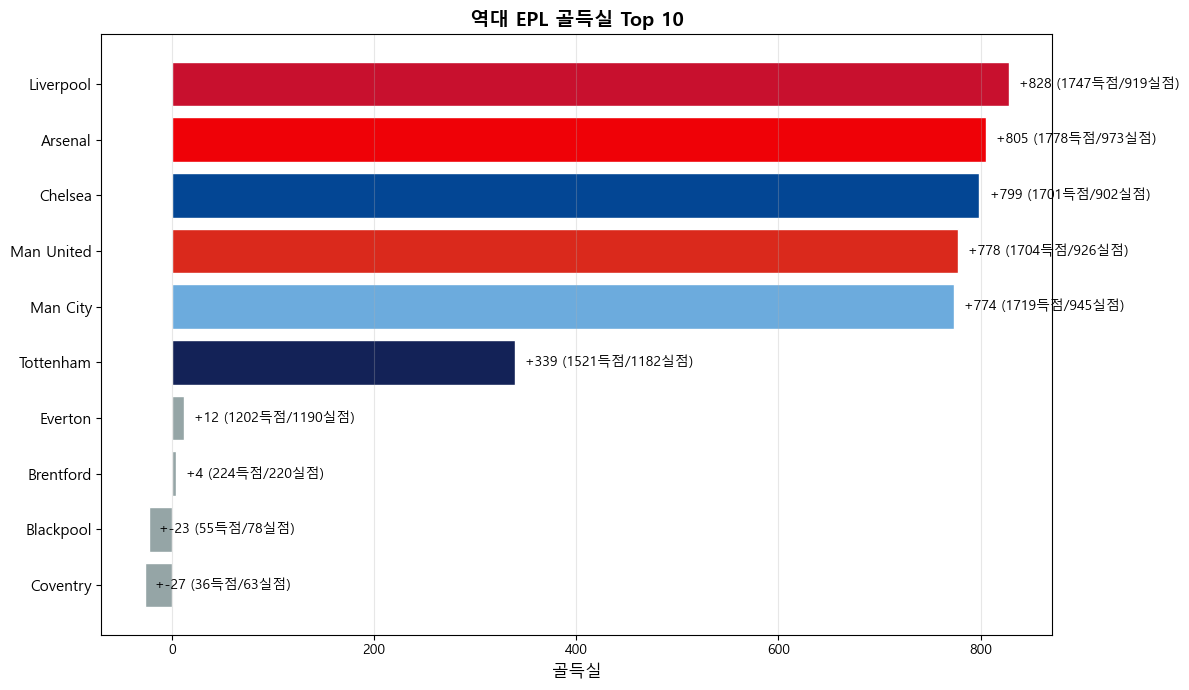

In [10]:
top10_gd = team_total.nlargest(10, 'goal_diff').sort_values('goal_diff')

fig, ax = plt.subplots(figsize=(12, 7))
colors = [BIG6_COLORS.get(t, '#95A5A6') for t in top10_gd['team']]
ax.barh(range(len(top10_gd)), top10_gd['goal_diff'], color=colors, edgecolor='white')
ax.set_yticks(range(len(top10_gd)))
ax.set_yticklabels(top10_gd['team'], fontsize=11)
ax.set_xlabel('골득실', fontsize=12)
ax.set_title('역대 EPL 골득실 Top 10', fontsize=14, fontweight='bold')

for i, (gd, gf, ga) in enumerate(zip(top10_gd['goal_diff'], top10_gd['total_gf'], top10_gd['total_ga'])):
    ax.text(gd + 10, i, f'+{gd} ({gf}득점/{ga}실점)', va='center', fontsize=10)

ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / 'eda_top10_goal_diff.png', dpi=150, bbox_inches='tight')
plt.show()


### 4.3 팀별 시즌 참가 히트맵

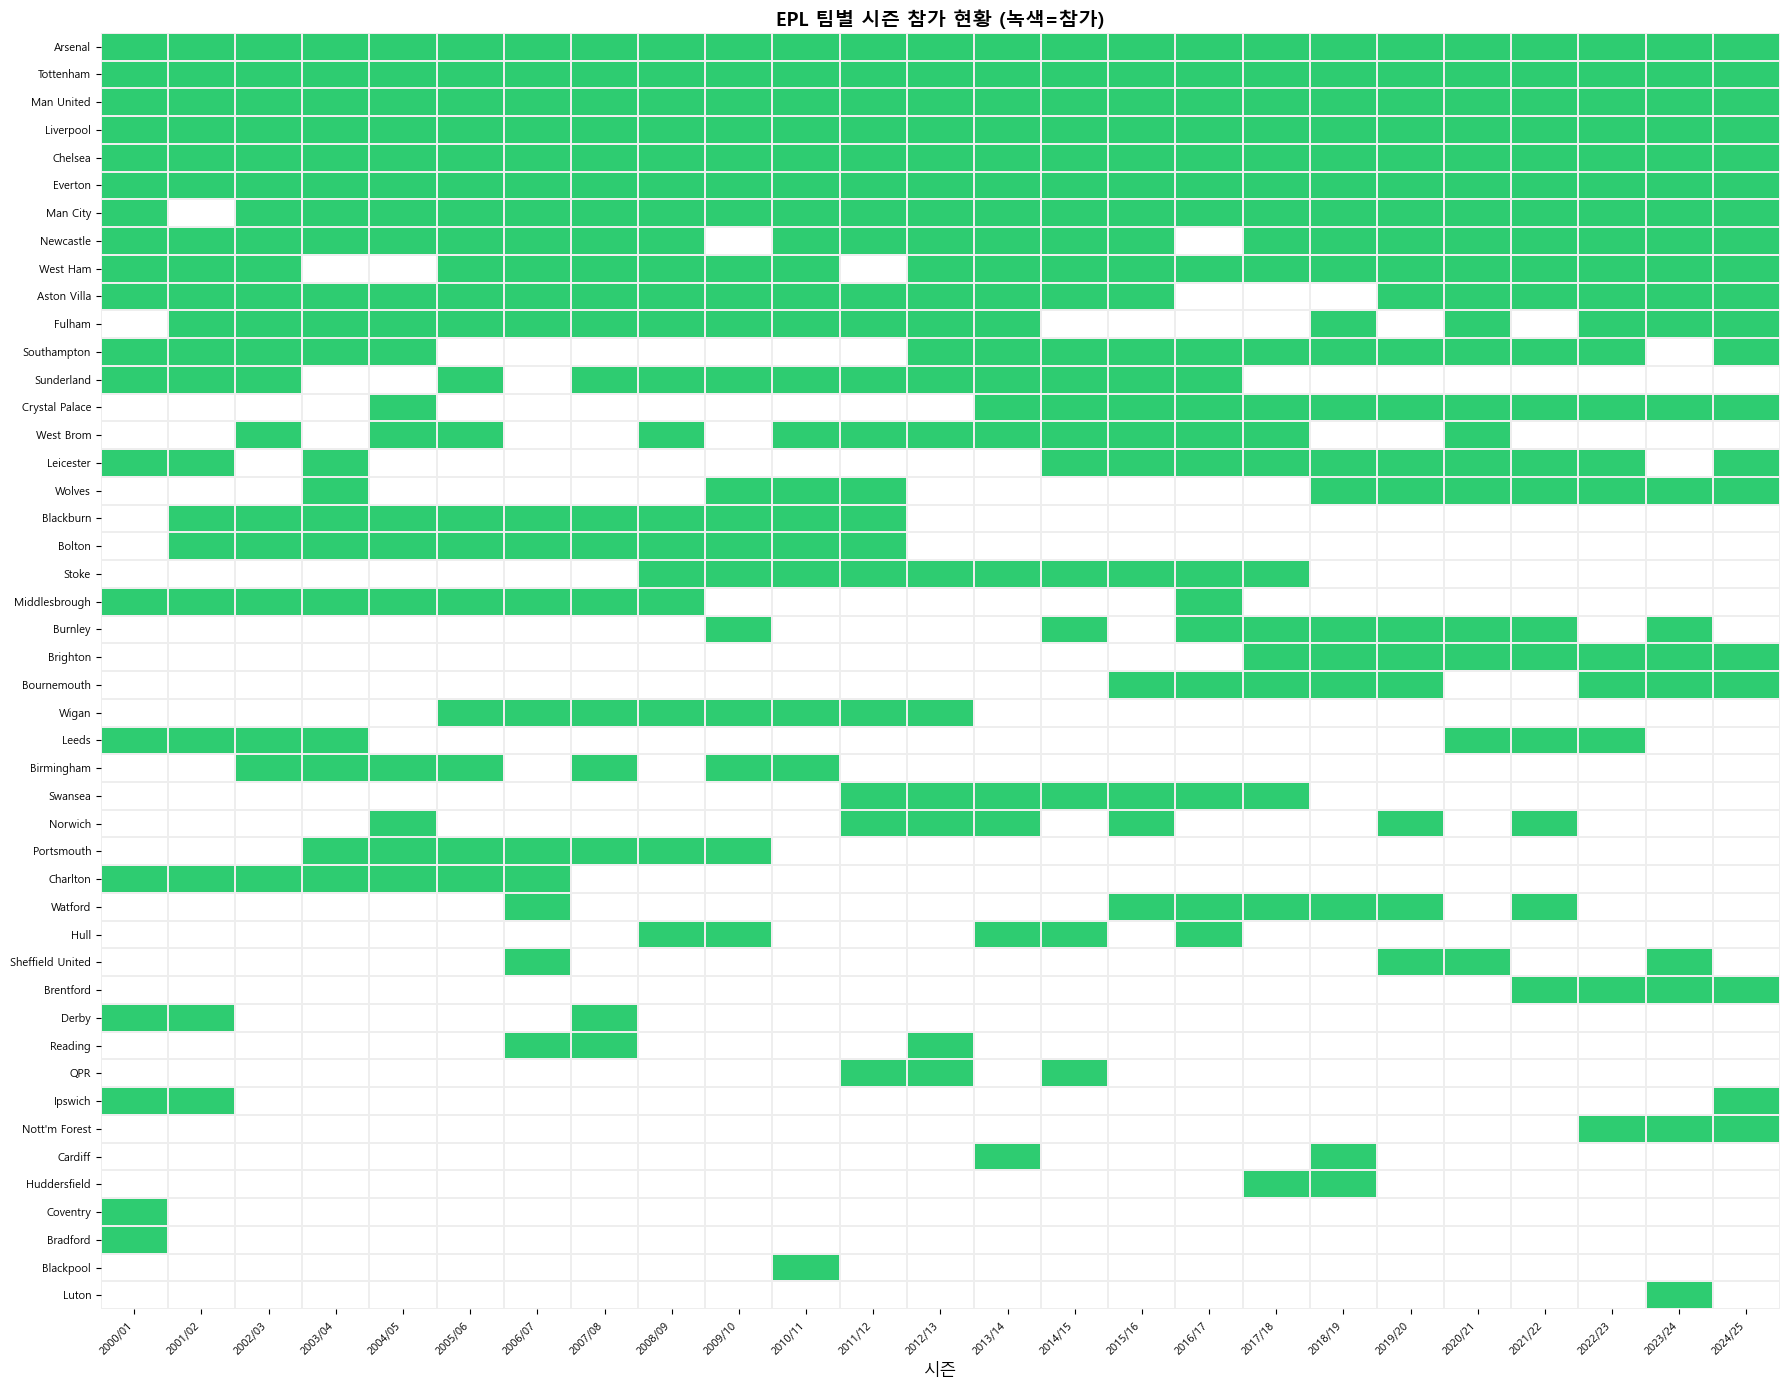

전 시즌 참가 팀 (6개): ['Arsenal', 'Tottenham', 'Man United', 'Liverpool', 'Chelsea', 'Everton']
총 참가 팀 수: 46


In [11]:
# 시즌 참가 히트맵
seasons = sorted(ts['Season'].unique())
teams_sorted = ts.groupby('team')['Season'].count().sort_values(ascending=False).index.tolist()

presence = pd.DataFrame(0, index=teams_sorted, columns=seasons)
for _, row in ts.iterrows():
    presence.loc[row['team'], row['Season']] = 1

fig, ax = plt.subplots(figsize=(18, 14))
sns.heatmap(presence, cmap=['#FFFFFF', '#2ECC71'], cbar=False, linewidths=0.3, linecolor='#EEEEEE', ax=ax)
ax.set_title('EPL 팀별 시즌 참가 현황 (녹색=참가)', fontsize=14, fontweight='bold')
ax.set_xlabel('시즌', fontsize=12)
ax.set_ylabel('')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig(FIG_DIR / 'eda_team_presence.png', dpi=150, bbox_inches='tight')
plt.show()

ever_present = [t for t in teams_sorted if presence.loc[t].sum() == len(seasons)]
print(f'전 시즌 참가 팀 ({len(ever_present)}개): {ever_present}')
print(f'총 참가 팀 수: {len(teams_sorted)}')


## 5. 선수 분석

### 5.1 연령 분포

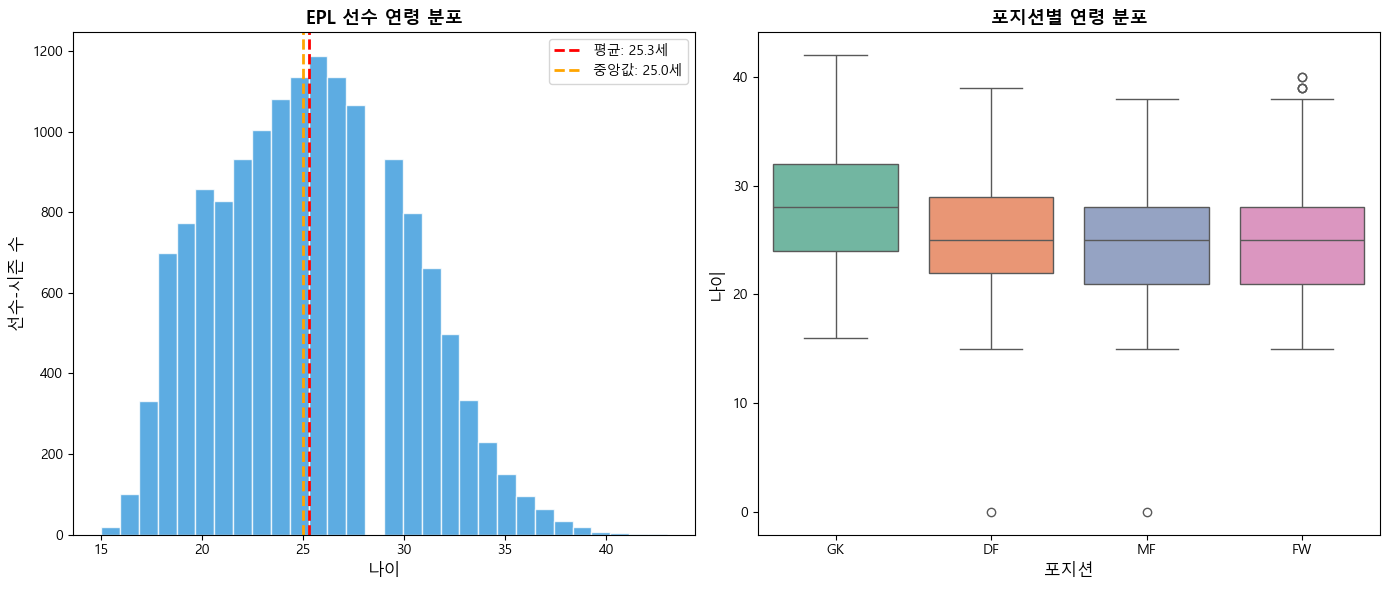

평균 나이: 25.3세, 중앙값: 25.0세
최연소: 15세, 최고령: 43세


In [12]:
ps = player_stats.copy()
ps['age_used'] = ps['age'].fillna(ps['age_tm'])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 전체 연령 분포
ax = axes[0]
valid_ages = ps['age_used'].dropna()
valid_ages = valid_ages[(valid_ages >= 15) & (valid_ages <= 45)]
ax.hist(valid_ages, bins=30, color='#3498DB', edgecolor='white', alpha=0.8)
ax.axvline(valid_ages.mean(), color='red', linestyle='--', linewidth=2, label=f'평균: {valid_ages.mean():.1f}세')
ax.axvline(valid_ages.median(), color='orange', linestyle='--', linewidth=2, label=f'중앙값: {valid_ages.median():.1f}세')
ax.set_xlabel('나이', fontsize=12)
ax.set_ylabel('선수-시즌 수', fontsize=12)
ax.set_title('EPL 선수 연령 분포', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)

# 포지션별 연령
ax = axes[1]
pos_map = {'GK': 'GK', 'DF': 'DF', 'MF': 'MF', 'FW': 'FW'}
ps['pos_main'] = ps['pos'].str.split(',').str[0]
pos_data = ps[ps['pos_main'].isin(['GK', 'DF', 'MF', 'FW']) & ps['age_used'].notna()]
pos_order = ['GK', 'DF', 'MF', 'FW']
sns.boxplot(data=pos_data, x='pos_main', y='age_used', order=pos_order, palette='Set2', ax=ax)
ax.set_xlabel('포지션', fontsize=12)
ax.set_ylabel('나이', fontsize=12)
ax.set_title('포지션별 연령 분포', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig(FIG_DIR / 'eda_age_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'평균 나이: {valid_ages.mean():.1f}세, 중앙값: {valid_ages.median():.1f}세')
print(f'최연소: {valid_ages.min():.0f}세, 최고령: {valid_ages.max():.0f}세')


### 5.2 포지션 분포

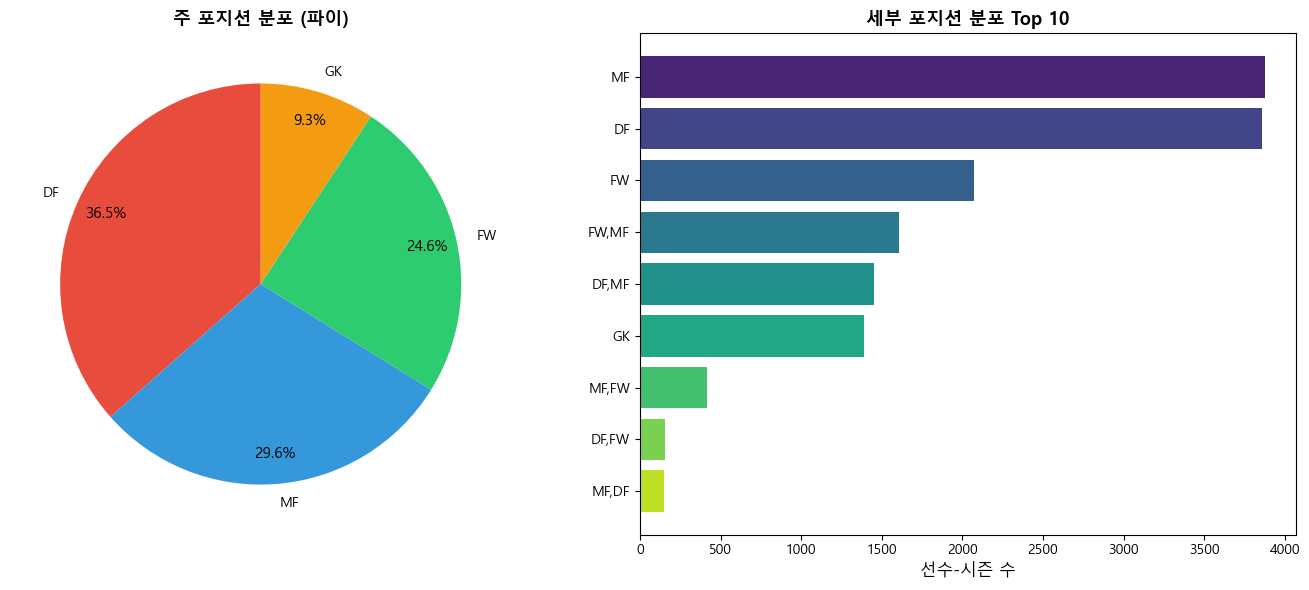

In [13]:
pos_counts = ps['pos_main'].value_counts()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# 파이 차트
colors_pie = ['#E74C3C', '#3498DB', '#2ECC71', '#F39C12', '#9B59B6']
wedges, texts, autotexts = ax1.pie(pos_counts.values, labels=pos_counts.index, autopct='%1.1f%%',
                                     colors=colors_pie[:len(pos_counts)], startangle=90, pctdistance=0.85)
for t in autotexts:
    t.set_fontsize(11)
ax1.set_title('주 포지션 분포 (파이)', fontsize=13, fontweight='bold')

# 세부 포지션 바 차트
detail_pos = ps['pos'].value_counts().head(10)
ax2.barh(range(len(detail_pos)), detail_pos.values, color=sns.color_palette('viridis', len(detail_pos)))
ax2.set_yticks(range(len(detail_pos)))
ax2.set_yticklabels(detail_pos.index, fontsize=10)
ax2.set_xlabel('선수-시즌 수', fontsize=12)
ax2.set_title('세부 포지션 분포 Top 10', fontsize=13, fontweight='bold')
ax2.invert_yaxis()

plt.tight_layout()
plt.savefig(FIG_DIR / 'eda_position_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


### 5.3 역대 득점 Top 20

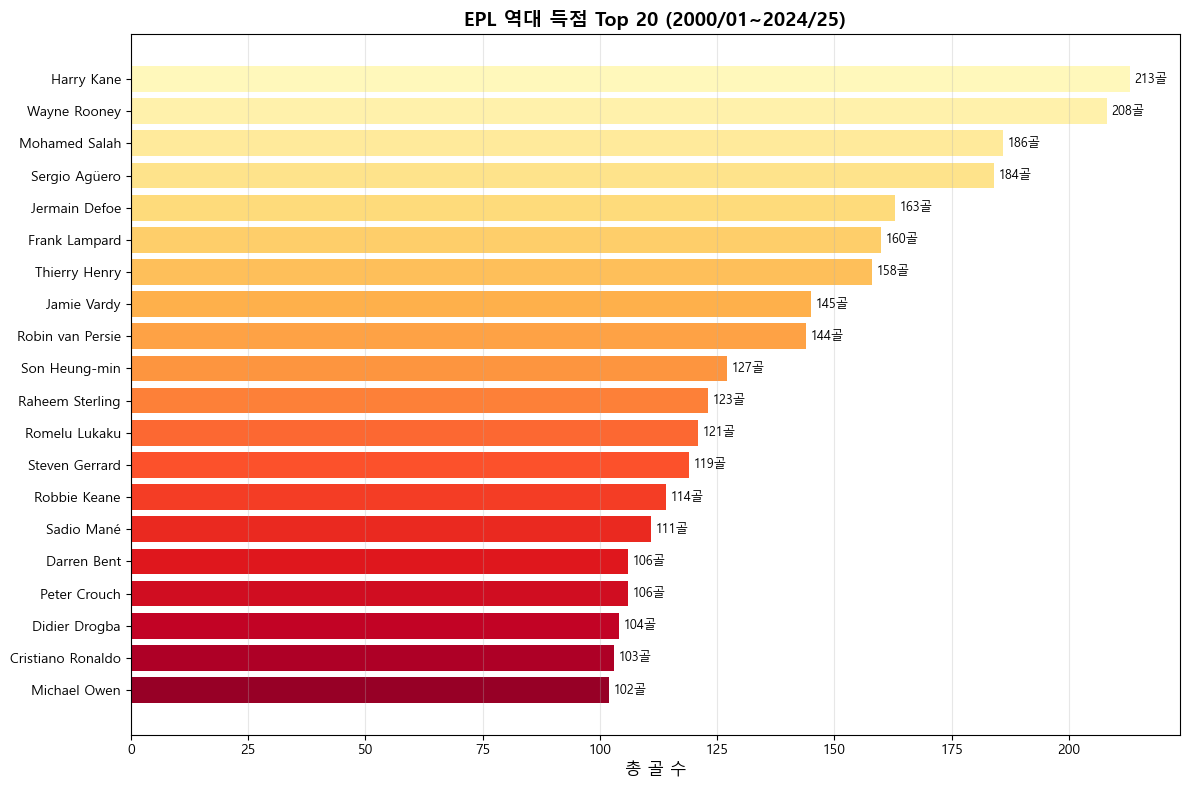

In [14]:
# 역대 득점왕
top_scorers = ps.groupby('player')['gls'].sum().nlargest(20).sort_values()

fig, ax = plt.subplots(figsize=(12, 8))
colors_bar = sns.color_palette('YlOrRd_r', len(top_scorers))
ax.barh(range(len(top_scorers)), top_scorers.values, color=colors_bar)
ax.set_yticks(range(len(top_scorers)))
ax.set_yticklabels(top_scorers.index, fontsize=10)
ax.set_xlabel('총 골 수', fontsize=12)
ax.set_title('EPL 역대 득점 Top 20 (2000/01~2024/25)', fontsize=14, fontweight='bold')

for i, v in enumerate(top_scorers.values):
    ax.text(v + 1, i, f'{int(v)}골', va='center', fontsize=9)

ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / 'eda_top20_scorers.png', dpi=150, bbox_inches='tight')
plt.show()


### 5.4 역대 시장가치 Top 20

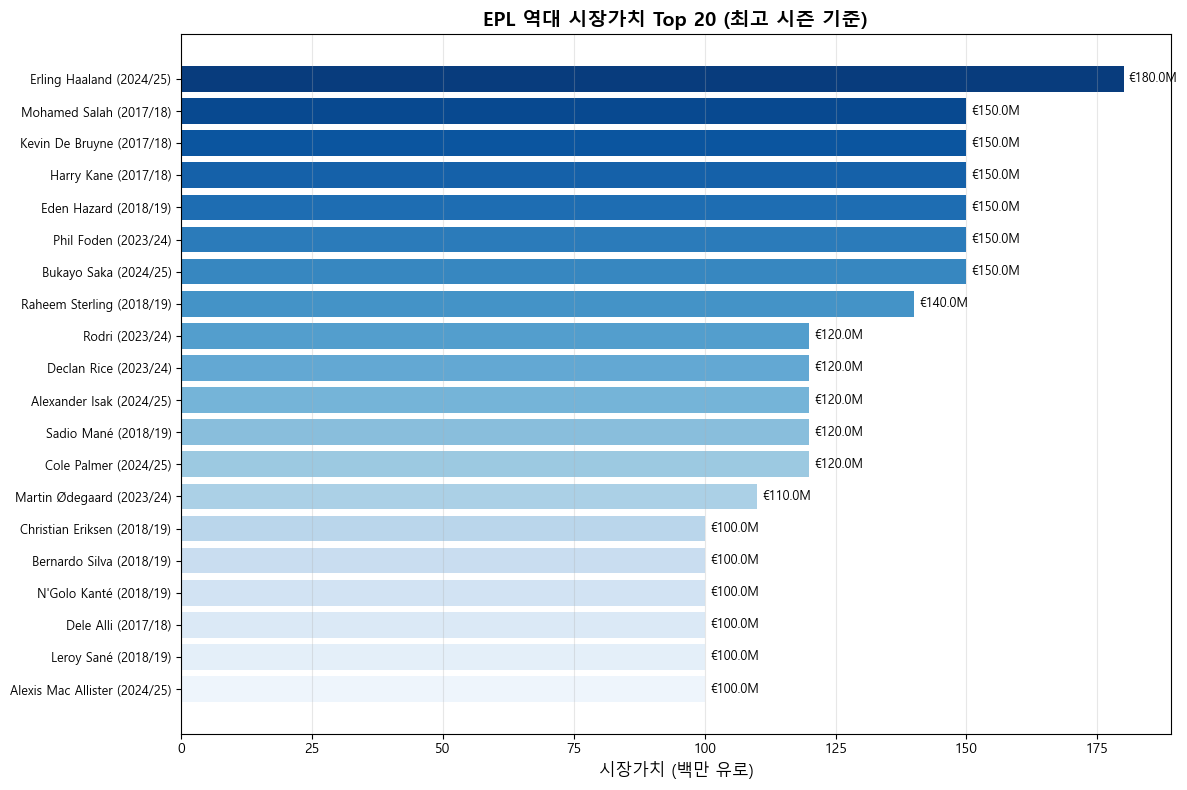

In [15]:
# 시장가치 Top 20 (최고 시즌 기준)
mv_top = ps[ps['market_value'].notna()].sort_values('market_value', ascending=False).drop_duplicates(subset='player').head(20)
mv_top = mv_top.sort_values('market_value')

fig, ax = plt.subplots(figsize=(12, 8))
colors_mv = sns.color_palette('Blues', len(mv_top))
ax.barh(range(len(mv_top)), mv_top['market_value'] / 1e6, color=colors_mv)
ax.set_yticks(range(len(mv_top)))
labels = [f"{row['player']} ({row['season']})" for _, row in mv_top.iterrows()]
ax.set_yticklabels(labels, fontsize=9)
ax.set_xlabel('시장가치 (백만 유로)', fontsize=12)
ax.set_title('EPL 역대 시장가치 Top 20 (최고 시즌 기준)', fontsize=14, fontweight='bold')

for i, v in enumerate(mv_top['market_value'] / 1e6):
    ax.text(v + 1, i, f'€{v:.1f}M', va='center', fontsize=9)

ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / 'eda_top20_market_value.png', dpi=150, bbox_inches='tight')
plt.show()


### 5.5 골 vs 시장가치 산점도

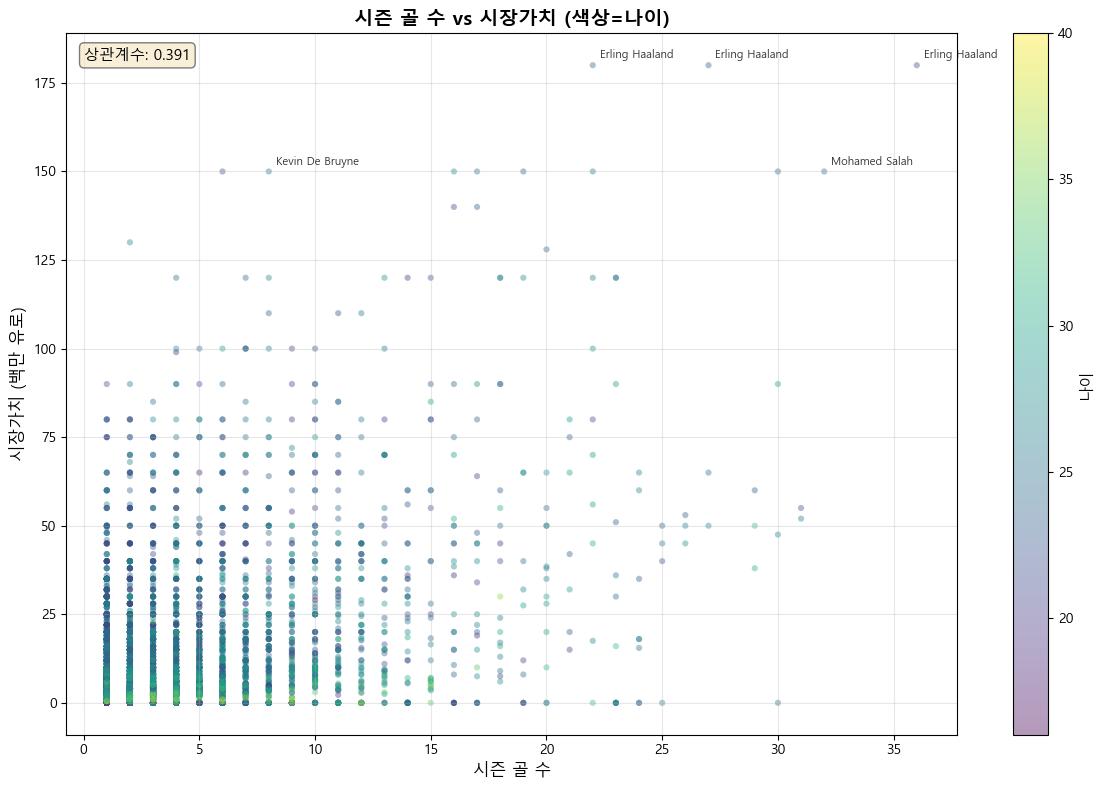

In [16]:
# 골 vs 시장가치
ps_mv = ps[(ps['market_value'].notna()) & (ps['gls'].notna()) & (ps['gls'] > 0)].copy()
ps_mv['mv_millions'] = ps_mv['market_value'] / 1e6

fig, ax = plt.subplots(figsize=(12, 8))
scatter = ax.scatter(ps_mv['gls'], ps_mv['mv_millions'],
                     c=ps_mv['age_used'], cmap='viridis', alpha=0.4, s=20, edgecolors='none')
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('나이', fontsize=11)
ax.set_xlabel('시즌 골 수', fontsize=12)
ax.set_ylabel('시장가치 (백만 유로)', fontsize=12)
ax.set_title('시즌 골 수 vs 시장가치 (색상=나이)', fontsize=14, fontweight='bold')

# Top players 라벨
top_labeled = ps_mv.nlargest(5, 'market_value')
for _, row in top_labeled.iterrows():
    ax.annotate(row['player'], (row['gls'], row['mv_millions']),
                fontsize=8, alpha=0.8, textcoords='offset points', xytext=(5, 5))

corr = ps_mv[['gls', 'mv_millions']].corr().iloc[0, 1]
ax.text(0.02, 0.98, f'상관계수: {corr:.3f}', transform=ax.transAxes, fontsize=11,
        va='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / 'eda_goals_vs_market_value.png', dpi=150, bbox_inches='tight')
plt.show()


## 6. 상관관계 분석

### 6.1 매치 피처 상관관계 히트맵

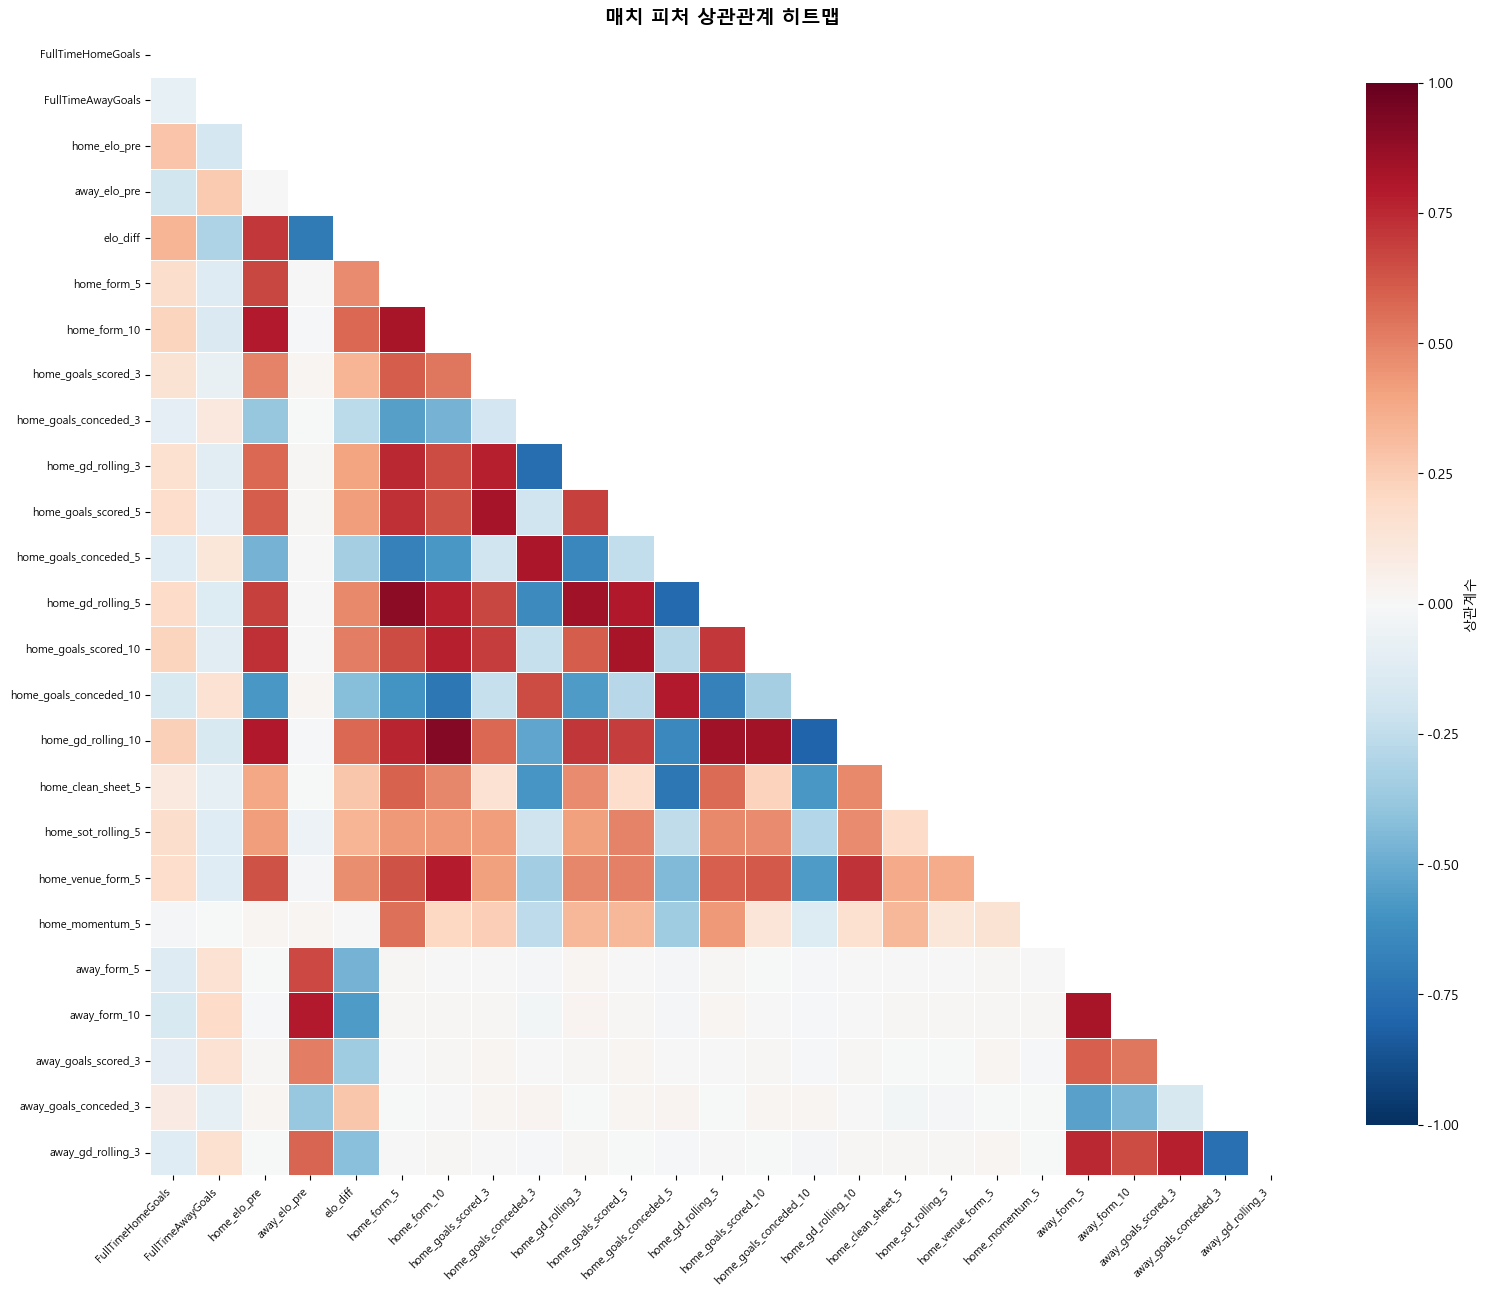

In [17]:
# 주요 매치 피처 상관관계
mf = match_features.copy()
# 수치형 컬럼 선택 (핵심 피처)
numeric_cols = [c for c in mf.select_dtypes(include=[np.number]).columns
                if not c.startswith('season') and c not in ['own_goal_flag_home', 'own_goal_flag_away', 'own_goal_flag', 'season_data_missing']]
# 핵심 피처만 선택
key_features = [c for c in numeric_cols if any(k in c for k in ['elo', 'form', 'goals_scored', 'goals_conceded',
                                                                  'gd_rolling', 'clean_sheet', 'sot_rolling',
                                                                  'h2h', 'momentum', 'FullTime'])]
if len(key_features) > 25:
    key_features = key_features[:25]

corr_matrix = mf[key_features].corr()

fig, ax = plt.subplots(figsize=(16, 14))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, cmap='RdBu_r', center=0, annot=False,
            square=True, linewidths=0.5, ax=ax, vmin=-1, vmax=1,
            cbar_kws={'label': '상관계수', 'shrink': 0.8})
ax.set_title('매치 피처 상관관계 히트맵', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig(FIG_DIR / 'eda_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


### 6.2 경기 결과와 주요 피처의 상관관계

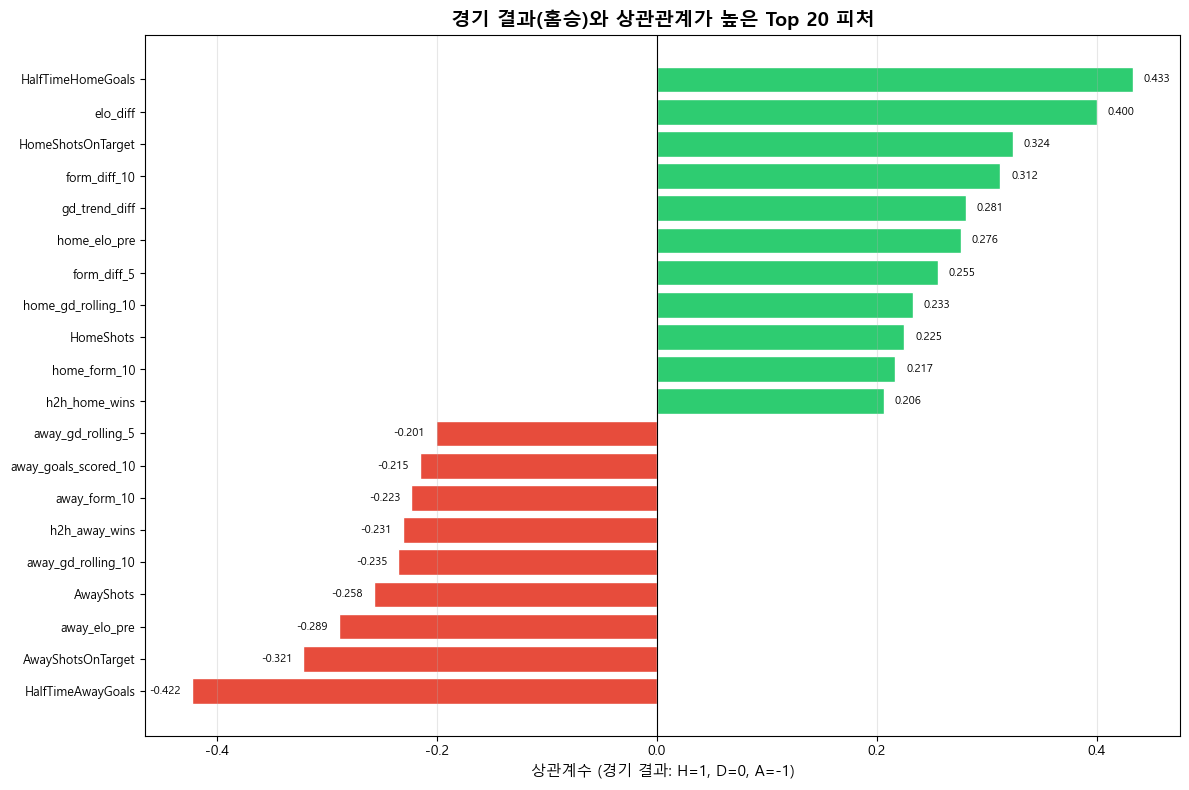

In [18]:
# 결과 인코딩
mf_encoded = mf.copy()
mf_encoded['result_numeric'] = mf_encoded['FullTimeResult'].map({'H': 1, 'D': 0, 'A': -1})

# 피처 vs 결과 상관
feature_cols = [c for c in mf.select_dtypes(include=[np.number]).columns
                if c not in ['FullTimeHomeGoals', 'FullTimeAwayGoals', 'season_year', 'season_data_missing',
                             'own_goal_flag_home', 'own_goal_flag_away', 'own_goal_flag', 'matchweek']]
corr_with_result = mf_encoded[feature_cols + ['result_numeric']].corr()['result_numeric'].drop('result_numeric')
corr_sorted = corr_with_result.abs().sort_values(ascending=False).head(20)
corr_top = corr_with_result[corr_sorted.index].sort_values()

fig, ax = plt.subplots(figsize=(12, 8))
colors_corr = ['#E74C3C' if v < 0 else '#2ECC71' for v in corr_top.values]
ax.barh(range(len(corr_top)), corr_top.values, color=colors_corr, edgecolor='white')
ax.set_yticks(range(len(corr_top)))
ax.set_yticklabels(corr_top.index, fontsize=9)
ax.set_xlabel('상관계수 (경기 결과: H=1, D=0, A=-1)', fontsize=11)
ax.set_title('경기 결과(홈승)와 상관관계가 높은 Top 20 피처', fontsize=14, fontweight='bold')
ax.axvline(x=0, color='black', linewidth=0.8)
ax.grid(axis='x', alpha=0.3)

for i, v in enumerate(corr_top.values):
    ax.text(v + (0.01 if v >= 0 else -0.01), i, f'{v:.3f}', va='center', fontsize=8,
            ha='left' if v >= 0 else 'right')

plt.tight_layout()
plt.savefig(FIG_DIR / 'eda_result_correlations.png', dpi=150, bbox_inches='tight')
plt.show()


## 7. 시대별 비교 (2000~2012 vs 2013~2025)

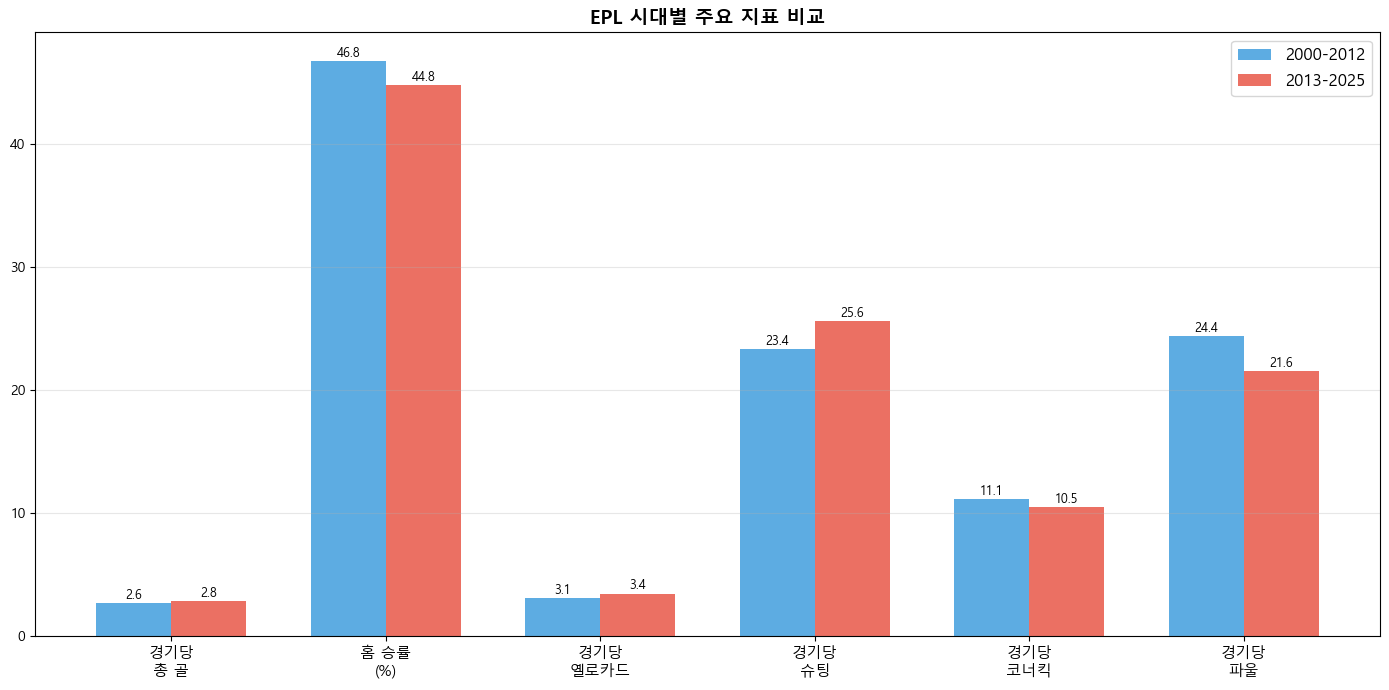


시대별 상세 비교:
      era  avg_goals  avg_home_goals  avg_away_goals  home_win_pct  avg_home_yellows  avg_away_yellows  avg_home_shots  avg_away_shots  avg_home_corners  avg_away_corners  avg_home_fouls  avg_away_fouls  matches  avg_yellows_total  avg_shots_total  avg_corners_total  avg_fouls_total
2000-2012   2.637320        1.522474        1.114845     46.762887          1.329485          1.769897       13.198557       10.154227          6.283299          4.836289       11.912577       12.504330     4850           3.099381        23.352784          11.119588        24.416907
2013-2025   2.804415        1.549227        1.255188     44.834437          1.616556          1.816556       14.066004       11.513466          5.780132          4.708830       10.595143       10.974834     4530           3.433113        25.579470          10.488962        21.569978


In [19]:
# 시대 구분
mr_era = mr.copy()
mr_era['year'] = mr_era['Season'].str[:4].astype(int)
mr_era['era'] = mr_era['year'].apply(lambda x: '2000-2012' if x < 2013 else '2013-2025')

era_stats = mr_era.groupby('era').agg(
    avg_goals=('TotalGoals', 'mean'),
    avg_home_goals=('FullTimeHomeGoals', 'mean'),
    avg_away_goals=('FullTimeAwayGoals', 'mean'),
    home_win_pct=('FullTimeResult', lambda x: (x == 'H').mean() * 100),
    avg_home_yellows=('HomeYellowCards', 'mean'),
    avg_away_yellows=('AwayYellowCards', 'mean'),
    avg_home_shots=('HomeShots', 'mean'),
    avg_away_shots=('AwayShots', 'mean'),
    avg_home_corners=('HomeCorners', 'mean'),
    avg_away_corners=('AwayCorners', 'mean'),
    avg_home_fouls=('HomeFouls', 'mean'),
    avg_away_fouls=('AwayFouls', 'mean'),
    matches=('TotalGoals', 'count')
).reset_index()

# 비교 시각화
metrics = {
    '경기당 총 골': ('avg_goals', '골'),
    '홈 승률': ('home_win_pct', '%'),
    '경기당 옐로카드 (합)': (None, '장'),
    '경기당 슈팅 (합)': (None, '회'),
    '경기당 코너킥 (합)': (None, '회'),
    '경기당 파울 (합)': (None, '회'),
}

era_stats['avg_yellows_total'] = era_stats['avg_home_yellows'] + era_stats['avg_away_yellows']
era_stats['avg_shots_total'] = era_stats['avg_home_shots'] + era_stats['avg_away_shots']
era_stats['avg_corners_total'] = era_stats['avg_home_corners'] + era_stats['avg_away_corners']
era_stats['avg_fouls_total'] = era_stats['avg_home_fouls'] + era_stats['avg_away_fouls']

compare_cols = ['avg_goals', 'home_win_pct', 'avg_yellows_total', 'avg_shots_total', 'avg_corners_total', 'avg_fouls_total']
compare_labels = ['경기당\n총 골', '홈 승률\n(%)', '경기당\n옐로카드', '경기당\n슈팅', '경기당\n코너킥', '경기당\n파울']

fig, ax = plt.subplots(figsize=(14, 7))
x = np.arange(len(compare_cols))
width = 0.35
era1 = era_stats[era_stats['era'] == '2000-2012'][compare_cols].values[0]
era2 = era_stats[era_stats['era'] == '2013-2025'][compare_cols].values[0]

bars1 = ax.bar(x - width/2, era1, width, label='2000-2012', color='#3498DB', alpha=0.8)
bars2 = ax.bar(x + width/2, era2, width, label='2013-2025', color='#E74C3C', alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels(compare_labels, fontsize=11)
ax.set_title('EPL 시대별 주요 지표 비교', fontsize=14, fontweight='bold')
ax.legend(fontsize=12)
ax.grid(axis='y', alpha=0.3)

for bar_group in [bars1, bars2]:
    for bar in bar_group:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., h + 0.1, f'{h:.1f}',
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(FIG_DIR / 'eda_era_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n시대별 상세 비교:')
print(era_stats.to_string(index=False))


## 8. 이적시장 분석

### 8.1 시즌별 평균 시장가치 추이

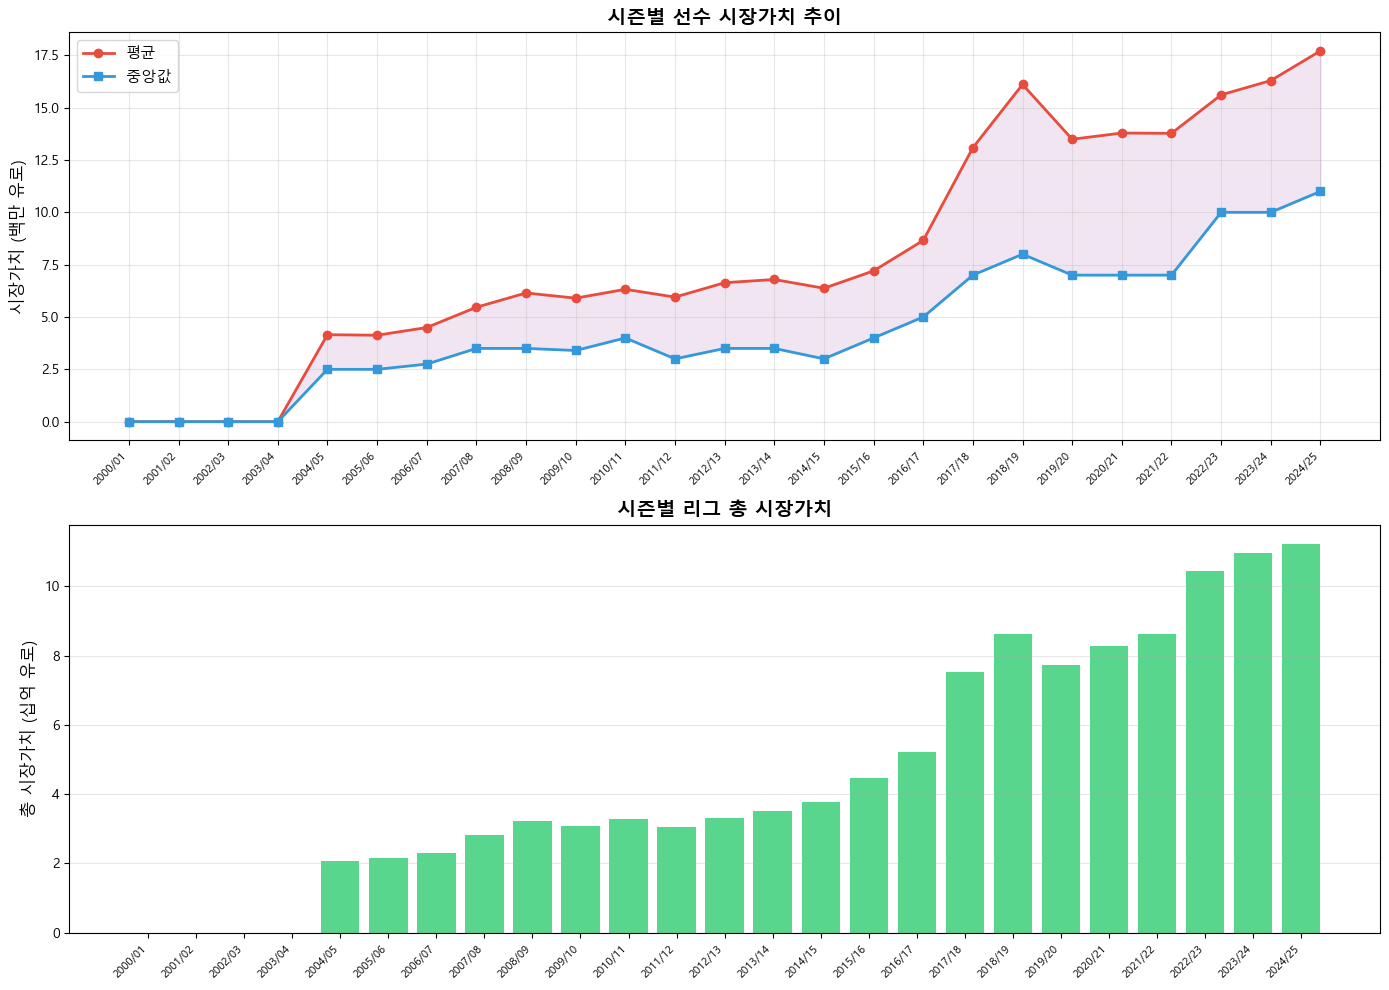

최근 시즌 평균 시장가치: €17.7M
최초 시즌 평균 시장가치: €0.0M
시장가치 성장률: inf%


In [20]:
# 시장가치 추이
ps_mv_all = ps[ps['market_value'].notna()].copy()
mv_by_season = ps_mv_all.groupby('season').agg(
    mean_mv=('market_value', 'mean'),
    median_mv=('market_value', 'median'),
    max_mv=('market_value', 'max'),
    total_mv=('market_value', 'sum'),
    player_count=('market_value', 'count')
).reset_index()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# 평균/중앙값 추이
ax1.plot(range(len(mv_by_season)), mv_by_season['mean_mv'] / 1e6, 'o-', color='#E74C3C', linewidth=2, label='평균')
ax1.plot(range(len(mv_by_season)), mv_by_season['median_mv'] / 1e6, 's-', color='#3498DB', linewidth=2, label='중앙값')
ax1.fill_between(range(len(mv_by_season)), mv_by_season['mean_mv'] / 1e6, mv_by_season['median_mv'] / 1e6, alpha=0.1, color='purple')
ax1.set_xticks(range(len(mv_by_season)))
ax1.set_xticklabels(mv_by_season['season'], rotation=45, ha='right', fontsize=8)
ax1.set_ylabel('시장가치 (백만 유로)', fontsize=12)
ax1.set_title('시즌별 선수 시장가치 추이', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(alpha=0.3)

# 총 시장가치
ax2.bar(range(len(mv_by_season)), mv_by_season['total_mv'] / 1e9, color='#2ECC71', alpha=0.8)
ax2.set_xticks(range(len(mv_by_season)))
ax2.set_xticklabels(mv_by_season['season'], rotation=45, ha='right', fontsize=8)
ax2.set_ylabel('총 시장가치 (십억 유로)', fontsize=12)
ax2.set_title('시즌별 리그 총 시장가치', fontsize=14, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / 'eda_market_value_trend.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'최근 시즌 평균 시장가치: €{mv_by_season.iloc[-1]["mean_mv"]/1e6:.1f}M')
print(f'최초 시즌 평균 시장가치: €{mv_by_season.iloc[0]["mean_mv"]/1e6:.1f}M')
growth = (mv_by_season.iloc[-1]['mean_mv'] / mv_by_season.iloc[0]['mean_mv'] - 1) * 100
print(f'시장가치 성장률: {growth:.0f}%')


### 8.2 포지션별 시장가치 분포

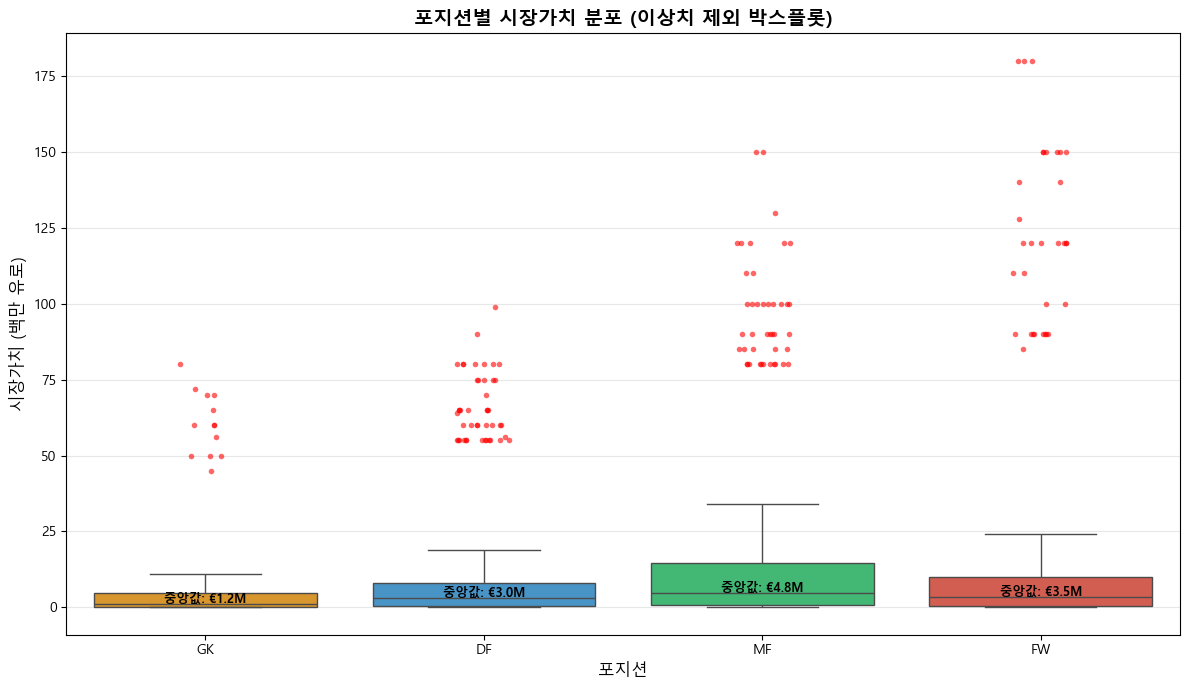

In [21]:
ps_mv_pos = ps_mv_all[ps_mv_all['pos'].str.split(',').str[0].isin(['GK', 'DF', 'MF', 'FW'])].copy()
ps_mv_pos['pos_main'] = ps_mv_pos['pos'].str.split(',').str[0]
ps_mv_pos['mv_millions'] = ps_mv_pos['market_value'] / 1e6

fig, ax = plt.subplots(figsize=(12, 7))
pos_order = ['GK', 'DF', 'MF', 'FW']
bp = sns.boxplot(data=ps_mv_pos, x='pos_main', y='mv_millions', order=pos_order,
                 palette={'GK': '#F39C12', 'DF': '#3498DB', 'MF': '#2ECC71', 'FW': '#E74C3C'},
                 showfliers=False, ax=ax)
sns.stripplot(data=ps_mv_pos[ps_mv_pos['mv_millions'] > ps_mv_pos.groupby('pos_main')['mv_millions'].transform('quantile', 0.99)],
              x='pos_main', y='mv_millions', order=pos_order, color='red', size=4, alpha=0.6, ax=ax)

ax.set_xlabel('포지션', fontsize=12)
ax.set_ylabel('시장가치 (백만 유로)', fontsize=12)
ax.set_title('포지션별 시장가치 분포 (이상치 제외 박스플롯)', fontsize=14, fontweight='bold')

# 중앙값 표시
medians = ps_mv_pos.groupby('pos_main')['mv_millions'].median()
for i, pos in enumerate(pos_order):
    ax.text(i, medians[pos] + 0.5, f'중앙값: €{medians[pos]:.1f}M', ha='center', fontsize=9, fontweight='bold')

ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / 'eda_market_value_by_position.png', dpi=150, bbox_inches='tight')
plt.show()


### 8.3 가장 비싼 스쿼드 Top 10

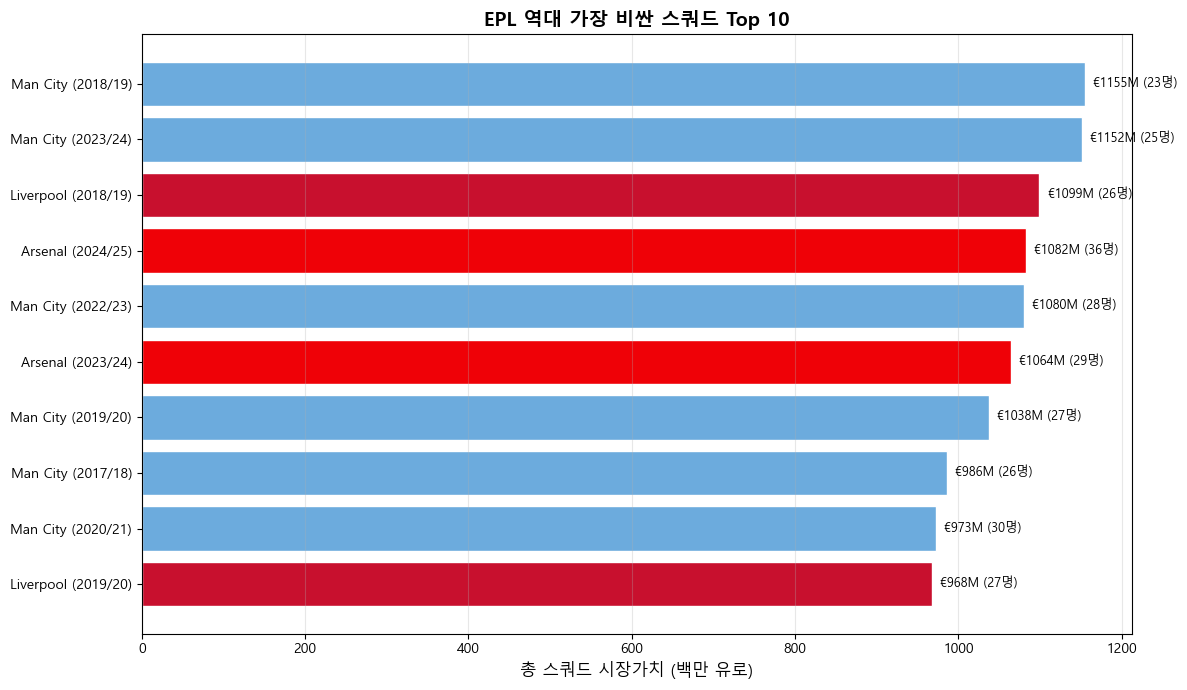

In [22]:
# 시즌별 팀 총 시장가치
squad_mv = ps_mv_all.groupby(['season', 'team']).agg(
    total_mv=('market_value', 'sum'),
    avg_mv=('market_value', 'mean'),
    squad_size=('market_value', 'count')
).reset_index()

top10_squads = squad_mv.nlargest(10, 'total_mv').sort_values('total_mv')

fig, ax = plt.subplots(figsize=(12, 7))
labels = [f"{row['team']} ({row['season']})" for _, row in top10_squads.iterrows()]
colors = [BIG6_COLORS.get(row['team'], '#95A5A6') for _, row in top10_squads.iterrows()]
ax.barh(range(len(top10_squads)), top10_squads['total_mv'] / 1e6, color=colors, edgecolor='white')
ax.set_yticks(range(len(top10_squads)))
ax.set_yticklabels(labels, fontsize=10)
ax.set_xlabel('총 스쿼드 시장가치 (백만 유로)', fontsize=12)
ax.set_title('EPL 역대 가장 비싼 스쿼드 Top 10', fontsize=14, fontweight='bold')

for i, row in enumerate(top10_squads.itertuples()):
    ax.text(row.total_mv / 1e6 + 10, i, f'€{row.total_mv/1e6:.0f}M ({row.squad_size}명)', va='center', fontsize=9)

ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / 'eda_top10_expensive_squads.png', dpi=150, bbox_inches='tight')
plt.show()


## 9. 파생변수 분석

### 9.1 ELO 레이팅 분포 및 추이

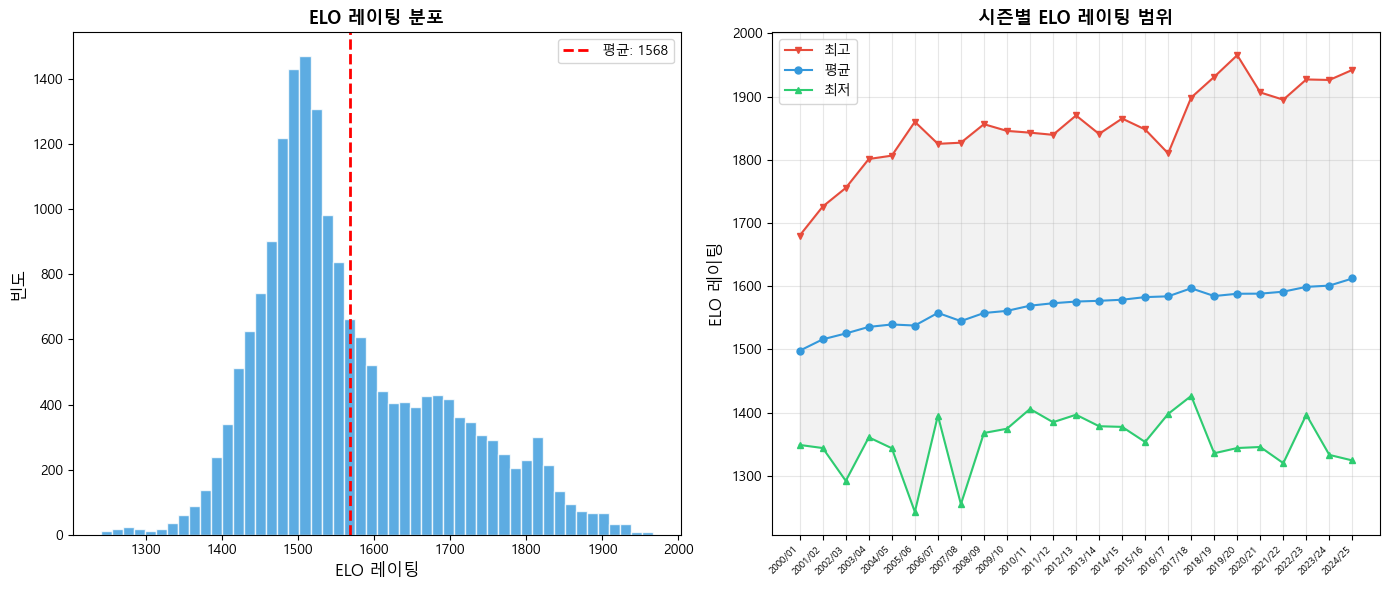

ELO 레이팅 범위: 1241 ~ 1967
평균: 1568, 표준편차: 122


In [23]:
mf = match_features.copy()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# ELO 분포
elo_data = pd.concat([mf['home_elo_pre'], mf['away_elo_pre']]).dropna()
ax1.hist(elo_data, bins=50, color='#3498DB', edgecolor='white', alpha=0.8)
ax1.axvline(elo_data.mean(), color='red', linestyle='--', linewidth=2, label=f'평균: {elo_data.mean():.0f}')
ax1.set_xlabel('ELO 레이팅', fontsize=12)
ax1.set_ylabel('빈도', fontsize=12)
ax1.set_title('ELO 레이팅 분포', fontsize=13, fontweight='bold')
ax1.legend()

# 시즌별 ELO 범위
elo_by_season = mf.groupby('Season').agg(
    mean_elo=('home_elo_pre', 'mean'),
    max_elo=('home_elo_pre', 'max'),
    min_elo=('home_elo_pre', 'min'),
    std_elo=('home_elo_pre', 'std')
).reset_index()

ax2.plot(range(len(elo_by_season)), elo_by_season['max_elo'], 'v-', color='#E74C3C', label='최고', markersize=5)
ax2.plot(range(len(elo_by_season)), elo_by_season['mean_elo'], 'o-', color='#3498DB', label='평균', markersize=5)
ax2.plot(range(len(elo_by_season)), elo_by_season['min_elo'], '^-', color='#2ECC71', label='최저', markersize=5)
ax2.fill_between(range(len(elo_by_season)), elo_by_season['max_elo'], elo_by_season['min_elo'], alpha=0.1, color='gray')
ax2.set_xticks(range(len(elo_by_season)))
ax2.set_xticklabels(elo_by_season['Season'], rotation=45, ha='right', fontsize=7)
ax2.set_ylabel('ELO 레이팅', fontsize=12)
ax2.set_title('시즌별 ELO 레이팅 범위', fontsize=13, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / 'eda_elo_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'ELO 레이팅 범위: {elo_data.min():.0f} ~ {elo_data.max():.0f}')
print(f'평균: {elo_data.mean():.0f}, 표준편차: {elo_data.std():.0f}')


### 9.2 폼 인덱스 분포

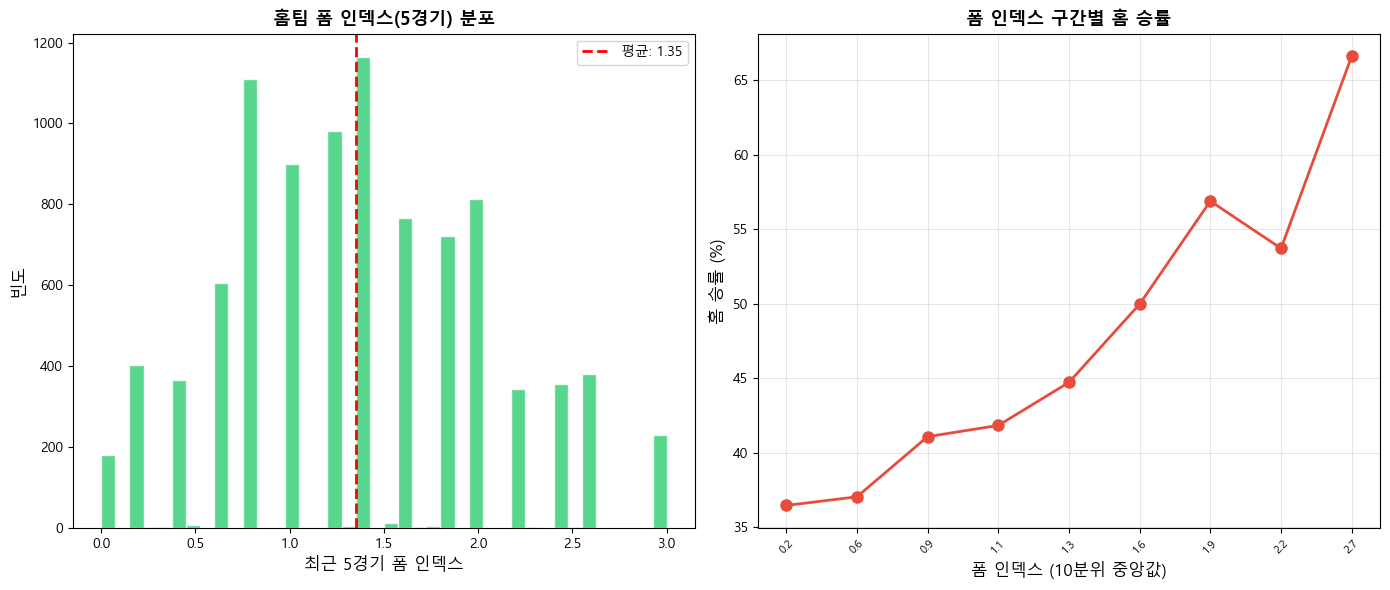

In [24]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# 홈팀 폼 분포
form5 = mf['home_form_5'].dropna()
ax1.hist(form5, bins=40, color='#2ECC71', edgecolor='white', alpha=0.8)
ax1.axvline(form5.mean(), color='red', linestyle='--', linewidth=2, label=f'평균: {form5.mean():.2f}')
ax1.set_xlabel('최근 5경기 폼 인덱스', fontsize=12)
ax1.set_ylabel('빈도', fontsize=12)
ax1.set_title('홈팀 폼 인덱스(5경기) 분포', fontsize=13, fontweight='bold')
ax1.legend()

# 폼 vs 승률
form_bins = pd.qcut(mf['home_form_5'].dropna(), 10, duplicates='drop')
mf_temp = mf.dropna(subset=['home_form_5']).copy()
mf_temp['form_bin'] = pd.qcut(mf_temp['home_form_5'], 10, duplicates='drop')
win_by_form = mf_temp.groupby('form_bin').apply(lambda x: (x['FullTimeResult'] == 'H').mean() * 100).reset_index()
win_by_form.columns = ['form_bin', 'home_win_pct']
win_by_form['form_mid'] = win_by_form['form_bin'].apply(lambda x: x.mid)
win_by_form = win_by_form.sort_values('form_mid')

ax2.plot(range(len(win_by_form)), win_by_form['home_win_pct'], 'o-', color='#E74C3C', linewidth=2, markersize=8)
ax2.set_xticks(range(len(win_by_form)))
ax2.set_xticklabels([f'{x:.1f}' for x in win_by_form['form_mid']], rotation=45, fontsize=8)
ax2.set_xlabel('폼 인덱스 (10분위 중앙값)', fontsize=12)
ax2.set_ylabel('홈 승률 (%)', fontsize=12)
ax2.set_title('폼 인덱스 구간별 홈 승률', fontsize=13, fontweight='bold')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / 'eda_form_index.png', dpi=150, bbox_inches='tight')
plt.show()


### 9.3 롤링 통계 효과성

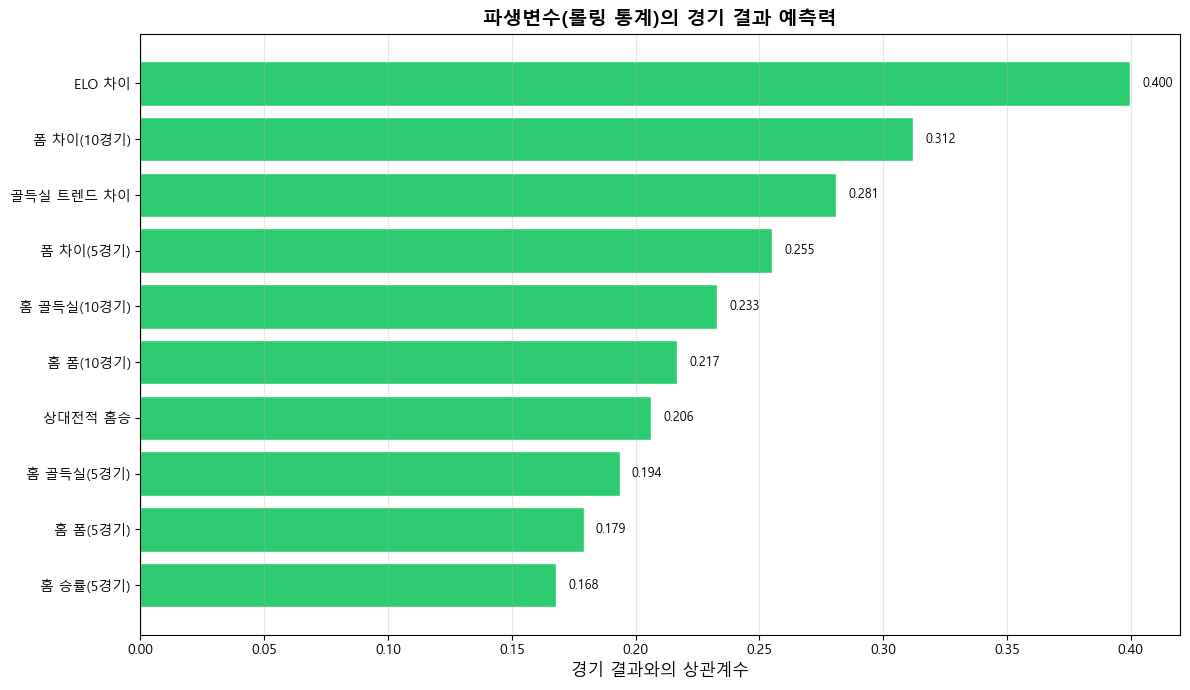


파생변수 예측력 순위 (|상관계수| 기준):
  ELO 차이                    r = +0.400
  폼 차이(10경기)                r = +0.312
  골득실 트렌드 차이                r = +0.281
  폼 차이(5경기)                 r = +0.255
  홈 골득실(10경기)               r = +0.233
  홈 폼(10경기)                 r = +0.217
  상대전적 홈승                   r = +0.206
  홈 골득실(5경기)                r = +0.194
  홈 폼(5경기)                  r = +0.179
  홈 승률(5경기)                 r = +0.168


In [25]:
# 롤링 통계별 결과 예측력
rolling_features = {
    'home_form_5': '홈 폼(5경기)',
    'home_form_10': '홈 폼(10경기)',
    'elo_diff': 'ELO 차이',
    'home_gd_rolling_5': '홈 골득실(5경기)',
    'home_gd_rolling_10': '홈 골득실(10경기)',
    'home_win_rate_5': '홈 승률(5경기)',
    'form_diff_5': '폼 차이(5경기)',
    'form_diff_10': '폼 차이(10경기)',
    'gd_trend_diff': '골득실 트렌드 차이',
    'h2h_home_wins': '상대전적 홈승',
}

mf_enc = mf.copy()
mf_enc['result_num'] = mf_enc['FullTimeResult'].map({'H': 1, 'D': 0, 'A': -1})
correlations = {}
for feat, label in rolling_features.items():
    if feat in mf_enc.columns:
        c = mf_enc[[feat, 'result_num']].dropna().corr().iloc[0, 1]
        correlations[label] = c

corr_df = pd.DataFrame(list(correlations.items()), columns=['피처', '상관계수'])
corr_df = corr_df.sort_values('상관계수', ascending=True)

fig, ax = plt.subplots(figsize=(12, 7))
colors_c = ['#E74C3C' if v < 0 else '#2ECC71' for v in corr_df['상관계수']]
ax.barh(range(len(corr_df)), corr_df['상관계수'], color=colors_c, edgecolor='white')
ax.set_yticks(range(len(corr_df)))
ax.set_yticklabels(corr_df['피처'], fontsize=10)
ax.set_xlabel('경기 결과와의 상관계수', fontsize=12)
ax.set_title('파생변수(롤링 통계)의 경기 결과 예측력', fontsize=14, fontweight='bold')
ax.axvline(x=0, color='black', linewidth=0.8)
ax.grid(axis='x', alpha=0.3)

for i, v in enumerate(corr_df['상관계수']):
    ax.text(v + (0.005 if v >= 0 else -0.005), i, f'{v:.3f}', va='center', fontsize=9,
            ha='left' if v >= 0 else 'right')

plt.tight_layout()
plt.savefig(FIG_DIR / 'eda_rolling_stats_effectiveness.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n파생변수 예측력 순위 (|상관계수| 기준):')
corr_df['abs_corr'] = corr_df['상관계수'].abs()
for _, row in corr_df.sort_values('abs_corr', ascending=False).iterrows():
    print(f'  {row["피처"]:<25} r = {row["상관계수"]:+.3f}')


## 10. 요약 및 주요 발견

이 EDA를 통해 발견한 주요 사항:

1. **데이터 규모**: 25시즌, 9,380경기, 14,980 선수-시즌 레코드
2. **홈 어드밴티지**: 시간이 지남에 따라 감소 추세, COVID-19 무관중 시즌에서 급격히 하락
3. **시장가치 인플레이션**: 25년간 선수 시장가치가 급격히 상승
4. **포지션별 차이**: 공격수(FW)의 시장가치가 가장 높음
5. **ELO/폼 인덱스**: 파생변수들이 경기 결과와 유의미한 상관관계를 보임
6. **시대별 변화**: 최근 시대에서 더 많은 골, 전술적 진화 관찰
